## Imports & Dependencies

In [1]:
#importing libraries
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from matplotlib.patches import Patch
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print('Using XGBoost')
except ImportError:
    XGB_AVAILABLE = False
    print('Using GradientBoostingClassifier')

# Inline plots
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Imports Completed')

Using GradientBoostingClassifier
Imports Completed


## CONFIG

Note: To update desired team update`FRANCHISE_NAME` variable.

In [2]:
class Config:
    # Defining File paths
    DELIVERIES_PATH  = 'deliveries.csv'
    MATCHES_PATH     = 'matches.csv'
    OUTPUT_DIR       = 'outputs'

    # Defining Target franchise 
    FRANCHISE_NAME   = 'Mumbai Indians'

    # Fix Historical name aliases 
    FRANCHISE_ALIASES = {
        'Delhi Daredevils'            : 'Delhi Capitals',
        'Kings XI Punjab'             : 'Punjab Kings',
        'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
        'Rising Pune Supergiant'      : 'Rising Pune Supergiants',
    }

    # Defining Role thresholds 
    MIN_BALLS_BATSMAN    = 200
    MIN_BALLS_BOWLER     = 150
    MIN_BALLS_ALLROUNDER = 150
    MIN_STUMPINGS_WK     = 3
    AR_BAT_THRESHOLD     = 150
    AR_BOWL_THRESHOLD    = 150

    # Defining Playing XI composition 
    XI_BATSMEN     = 4
    XI_WK          = 1
    XI_ALLROUNDERS = 3
    XI_BOWLERS     = 3

    # Defining Model settings 
    WP_CV_FOLDS      = 5
    WP_SUBSAMPLE     = 50_000
    EVIDENCE_K       = 30       # (Constant for Bayesian shrinkage)
    RANDOM_STATE     = 1908122  # Student ID number as random state
    RECENT_N_SEASONS = 4

    ROLE_PALETTE = {
        'Batsman'     : '#4C72B0',
        'Wicketkeeper': '#C8A951',
        'All-rounder' : '#55A868',
        'Bowler'      : '#C44E52',
        'Unknown'     : '#8C8C8C',
    }

    @classmethod
    def setup(cls):
        os.makedirs(cls.OUTPUT_DIR, exist_ok=True)
        np.random.seed(cls.RANDOM_STATE)

    @classmethod
    def normalise_team(cls, name: str) -> str:
        return cls.FRANCHISE_ALIASES.get(name, name)


cfg = Config()
cfg.setup()
print(f' Config ready, selected Franchise: {cfg.FRANCHISE_NAME}')
print(f' Output dir : {os.path.abspath(cfg.OUTPUT_DIR)}')

 Config ready, selected Franchise: Mumbai Indians
 Output dir : /Users/tanishqdureja/Downloads/outputs


## Data Loading & EDA



In [3]:
# Read datasets
deliveries = pd.read_csv(cfg.DELIVERIES_PATH)
matches    = pd.read_csv(cfg.MATCHES_PATH)
print(f'  deliveries : {deliveries.shape}')
print(f'  matches    : {matches.shape}')

# Normalise franchise names in matches
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].map(
        lambda x: cfg.normalise_team(str(x)) if pd.notna(x) else x
    )

# Merge match metadata onto deliveries
meta_cols = ['id', 'season', 'date', 'venue', 'winner', 'target_runs', 'target_overs']
meta = matches[meta_cols].rename(columns={'id': 'match_id'})
df   = deliveries.merge(meta, on='match_id', how='left')

for col in ['batting_team', 'bowling_team']:
    df[col] = df[col].map(
        lambda x: cfg.normalise_team(str(x)) if pd.notna(x) else x
    )

df['batting_team_won'] = (df['batting_team'] == df['winner']).astype(int)

print(f'\n  Merged shape : {df.shape}')
df.head()

  deliveries : (260920, 17)
  matches    : (1095, 20)

  Merged shape : (260920, 24)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,player_dismissed,dismissal_kind,fielder,season,date,venue,winner,target_runs,target_overs,batting_team_won
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,NaN,NaN,NaN,2007/08,18/4/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,223.0,20.0,1
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,NaN,2007/08,18/4/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,223.0,20.0,1
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,NaN,2007/08,18/4/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,223.0,20.0,1
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,NaN,2007/08,18/4/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,223.0,20.0,1
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,NaN,2007/08,18/4/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,223.0,20.0,1


### EDA — Missing Values

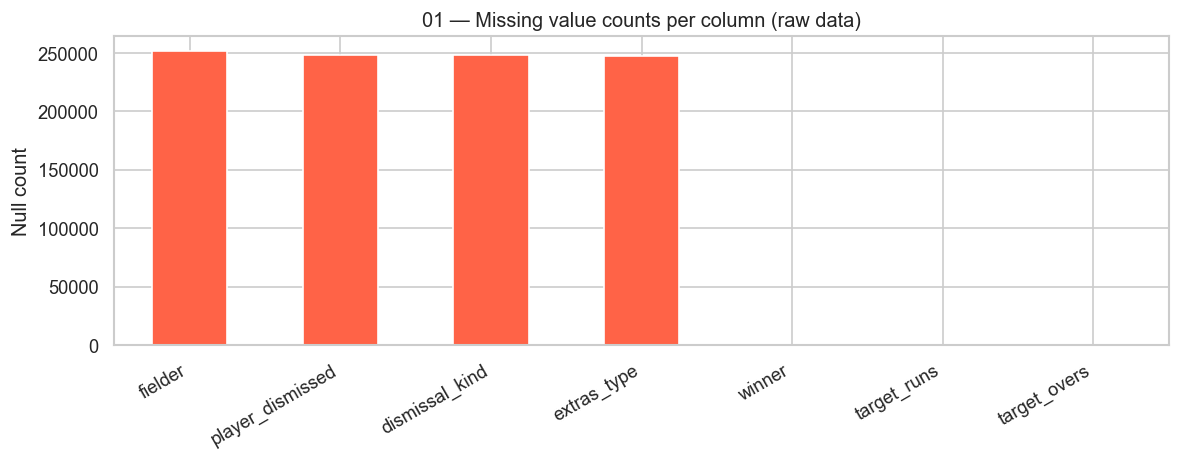

In [4]:
# Performing EDA null checks
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
# Visualisation
if null_counts.empty:
    print(' No missing values in the dataset.')
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    null_counts.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title('01 — Missing value counts per column (raw data)')
    ax.set_ylabel('Null count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

### EDA — Runs per Over

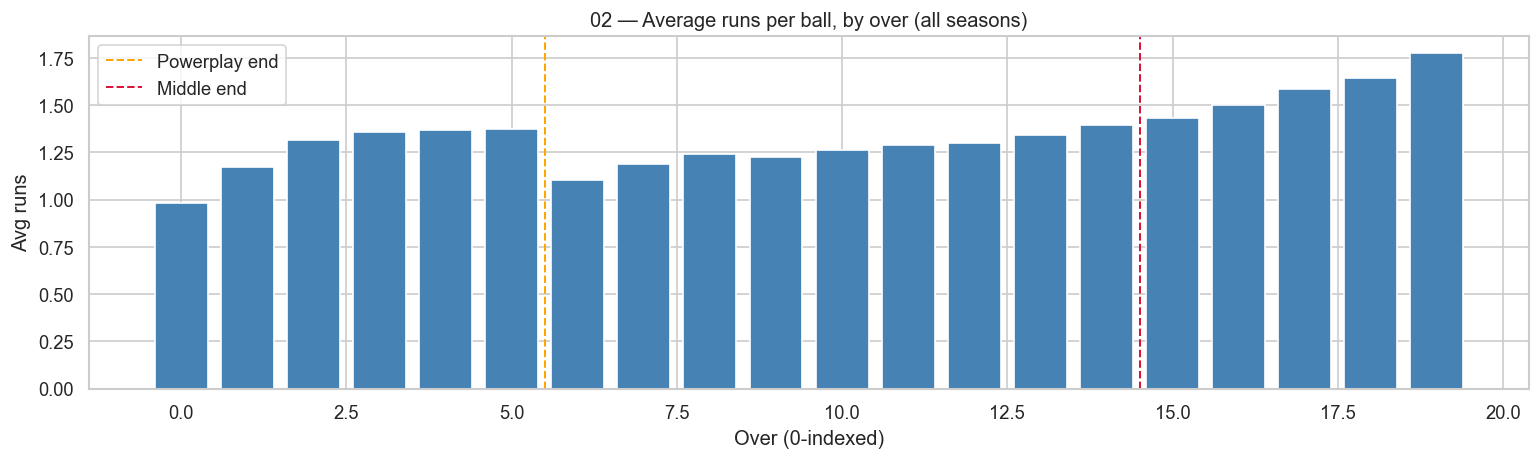

In [5]:
# Distribution of runs across overs
avg = df.groupby('over')['total_runs'].mean()
# Visualisation
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(avg.index, avg.values, color='steelblue', edgecolor='white')
ax.set_title('02 — Average runs per ball, by over (all seasons)')
ax.set_xlabel('Over (0-indexed)')
ax.set_ylabel('Avg runs')
ax.axvline(5.5,  color='orange', ls='--', lw=1.2, label='Powerplay end')
ax.axvline(14.5, color='crimson', ls='--', lw=1.2, label='Middle end')
ax.legend()
plt.tight_layout()
plt.show()

### EDA — Wicket Rate per Over

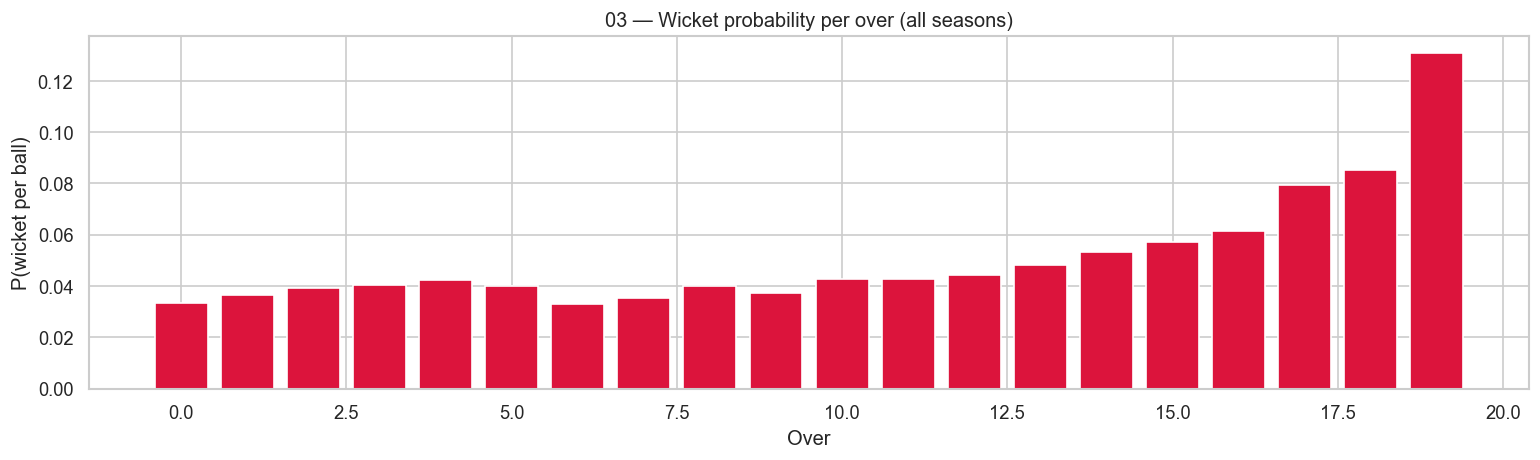

In [6]:
# Distribution of wickets across overs
rate = df.groupby('over')['is_wicket'].mean()
# Visualisation
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(rate.index, rate.values, color='crimson', edgecolor='white')
ax.set_title('03 — Wicket probability per over (all seasons)')
ax.set_xlabel('Over')
ax.set_ylabel('P(wicket per ball)')
plt.tight_layout()
plt.show()

### EDA — Batting-team Win Rate by Phase

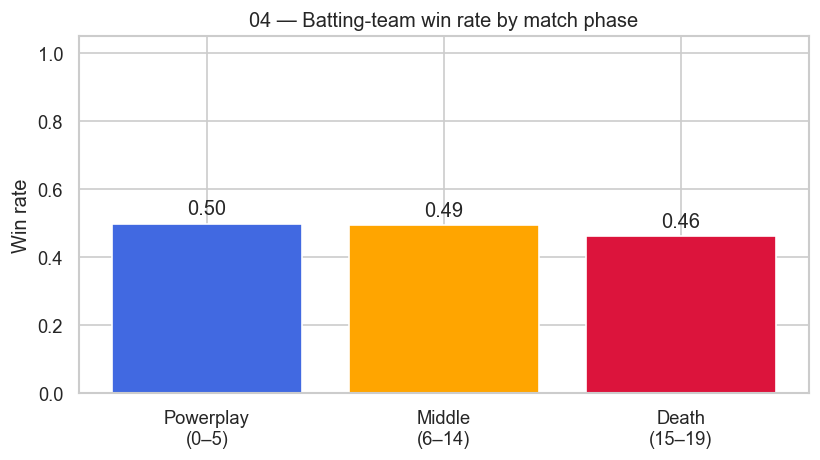

In [7]:
bins   = [-1, 5, 14, 19]
labels = ['Powerplay\n(0–5)', 'Middle\n(6–14)', 'Death\n(15–19)']
tmp    = df.copy()
tmp['phase'] = pd.cut(tmp['over'], bins=bins, labels=labels)
wr = tmp.groupby('phase', observed=True)['batting_team_won'].mean()
# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(wr.index.astype(str), wr.values,
              color=['royalblue', 'orange', 'crimson'], edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylim(0, 1.05)
ax.set_title('04 — Batting-team win rate by match phase')
ax.set_ylabel('Win rate')
plt.tight_layout()
plt.show()

### EDA — Matches per Season

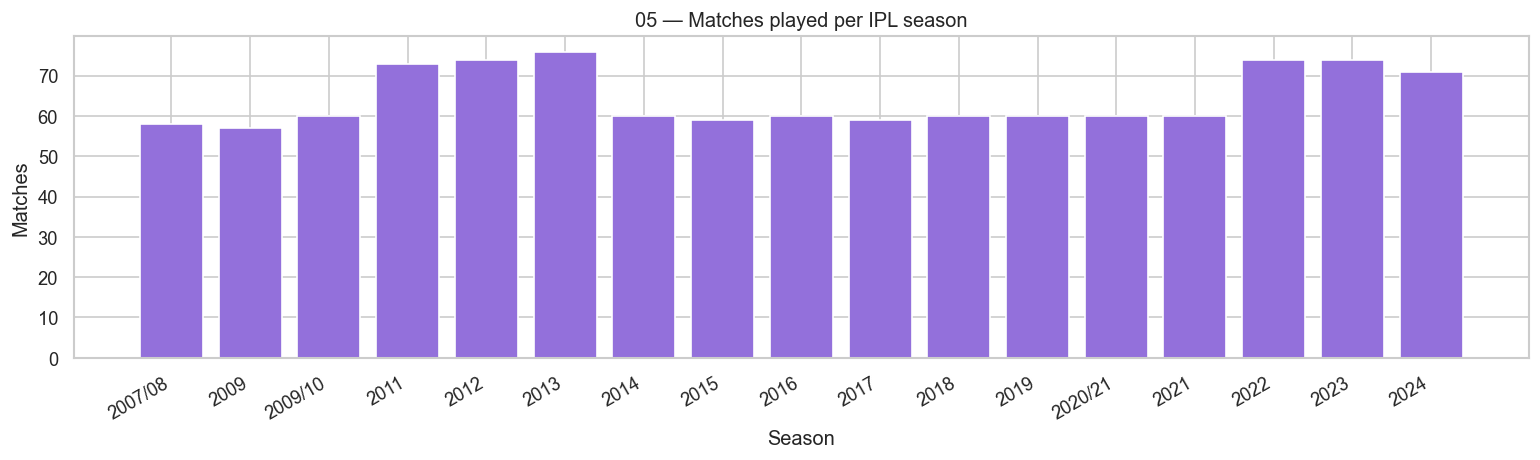

In [8]:
counts = matches['season'].value_counts().sort_index()
# Visualisation
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(counts.index.astype(str), counts.values, color='mediumpurple', edgecolor='white')
ax.set_title('05 — Matches played per IPL season')
ax.set_xlabel('Season')
ax.set_ylabel('Matches')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### EDA — Deliveries per Franchise

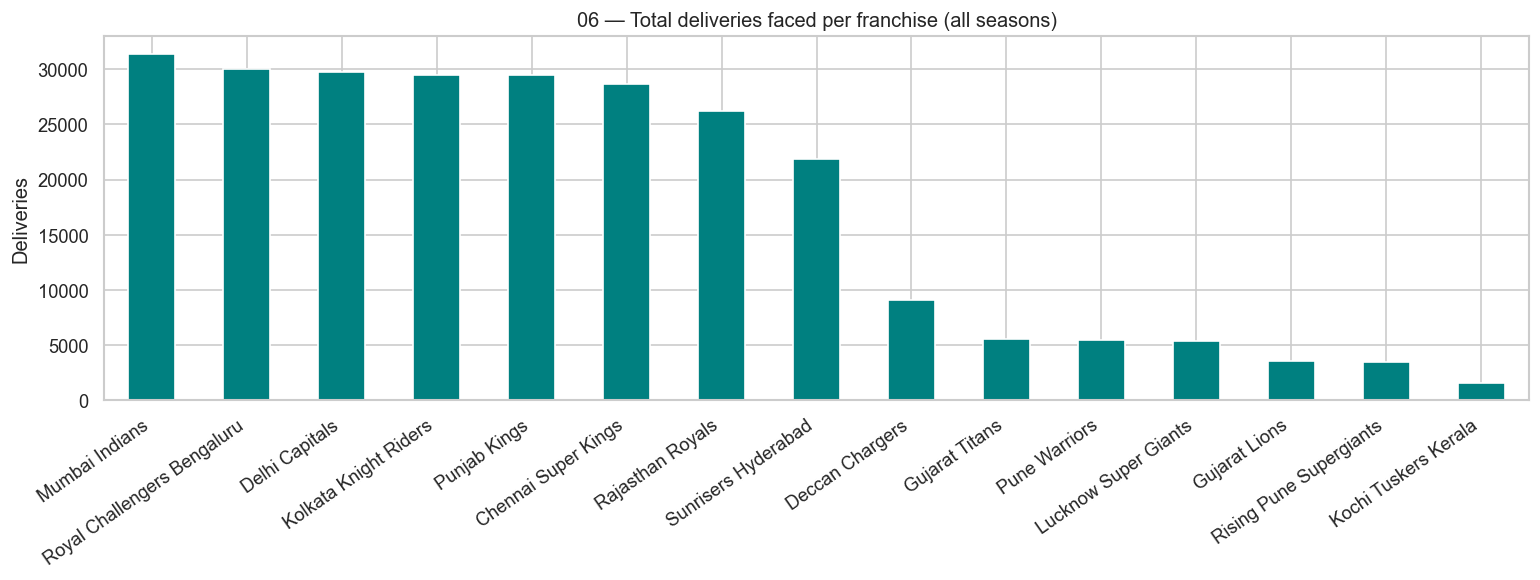

In [9]:
team_counts = df['batting_team'].value_counts()
# Visualisation
fig, ax = plt.subplots(figsize=(13, 5))
team_counts.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('06 — Total deliveries faced per franchise (all seasons)')
ax.set_ylabel('Deliveries')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## Performing Data Cleaning

Filter to standard innings, drop duplicates, fill nulls, coerce dtypes.

In [10]:
n_raw = len(df)

# Filter to innings 1 & 2 only
df = df[df['inning'].isin([1, 2])].copy()
n_after_inn = len(df)

# Drop duplicate deliveries
df = df.drop_duplicates(subset=['match_id', 'inning', 'over', 'ball'], keep='first')
n_after_dupe = len(df)

# Fill nulls
fill_map = {
    'extras_type'     : 'legal',
    'dismissal_kind'  : 'not_out',
    'player_dismissed': 'not_out',
    'fielder'         : 'none',
    'winner'          : 'no_result',
    'target_runs'     : 0,
    'target_overs'    : 20,
}
df = df.fillna(fill_map)
df['batting_team_won'] = (df['batting_team'] == df['winner']).astype(int)

# Coerce numeric types
int_cols = ['match_id', 'inning', 'over', 'ball',
            'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket', 'target_runs']
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df = df.dropna(subset=['batter', 'bowler'])
df = df.sort_values(['match_id', 'inning', 'over', 'ball']).reset_index(drop=True)

n_final = len(df)
print(f'  Raw rows              : {n_raw:,}')
print(f'  After innings filter  : {n_after_inn:,}')
print(f'  After duplicate drop  : {n_after_dupe:,}')
print(f'  Final cleaned shape   : {df.shape}')

  Raw rows              : 260,920
  After innings filter  : 260,759
  After duplicate drop  : 260,759
  Final cleaned shape   : (260759, 24)


### Cleaning Audit — Row Counts

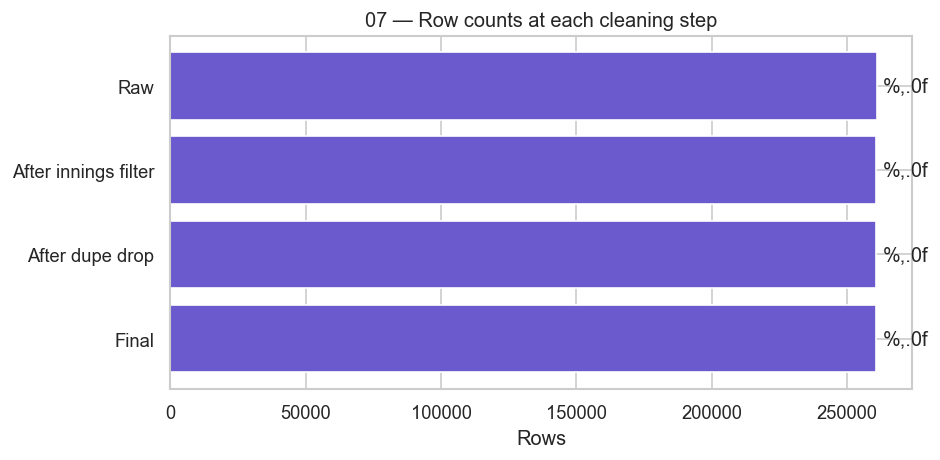

In [11]:
cleaning_counts = {
    'Raw'                : n_raw,
    'After innings filter': n_after_inn,
    'After dupe drop'    : n_after_dupe,
    'Final'              : n_final,
}
# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    list(cleaning_counts.keys()),
    list(cleaning_counts.values()),
    color='slateblue', edgecolor='white'
)
ax.bar_label(bars, fmt='%,.0f', padding=4)
ax.set_title('07 — Row counts at each cleaning step')
ax.set_xlabel('Rows')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Feature Engineering

### a) Delivery-level Context Features

In [12]:
# Ball index and resource state
df['ball_idx']       = df.groupby(['match_id', 'inning']).cumcount()
df['balls_remaining']= (120 - df['ball_idx']).clip(lower=0)

# Cumulative runs/wickets BEFORE this delivery
df['cum_runs']    = (df.groupby(['match_id', 'inning'])['total_runs'].cumsum()
                      - df['total_runs'])
df['cum_wickets'] = (df.groupby(['match_id', 'inning'])['is_wicket'].cumsum()
                      - df['is_wicket'])
df['wickets_remaining'] = (10 - df['cum_wickets']).clip(lower=0)

# Target / runs required (2nd innings)
inn1_totals = (df[df['inning'] == 1]
               .groupby('match_id')['total_runs'].sum()
               .rename('inn1_total'))
df = df.join(inn1_totals, on='match_id')
df['inn1_total']    = df['inn1_total'].fillna(0)
df['runs_required'] = np.where(
    df['inning'] == 2,
    (df['inn1_total'] + 1 - df['cum_runs']).clip(lower=0),
    0
)

# Run rates
overs_so_far     = (df['ball_idx'] / 6).clip(lower=0.01)
df['current_rr'] = df['cum_runs'] / overs_so_far
df['rrr']        = np.where(
    df['balls_remaining'] > 0,
    df['runs_required'] / (df['balls_remaining'] / 6),
    0.0
).clip(0, 36)
df['run_rate_last30'] = (
    df.groupby(['match_id', 'inning'])['total_runs']
      .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

# Phase flags
df['is_powerplay'] = (df['over'] <= 5).astype(int)
df['is_middle']    = ((df['over'] > 5) & (df['over'] <= 14)).astype(int)
df['is_death']     = (df['over'] > 14).astype(int)

# Batting position proxy
df['bat_position'] = (
    df.groupby(['match_id', 'inning'])['batter']
      .transform(lambda x: x.ne(x.shift()).cumsum())
)

print(f'Delivery features shape: {df.shape}')

Delivery features shape: (260759, 38)


### Feature Plot — Run Rate vs Required Run Rate (2nd Innings)

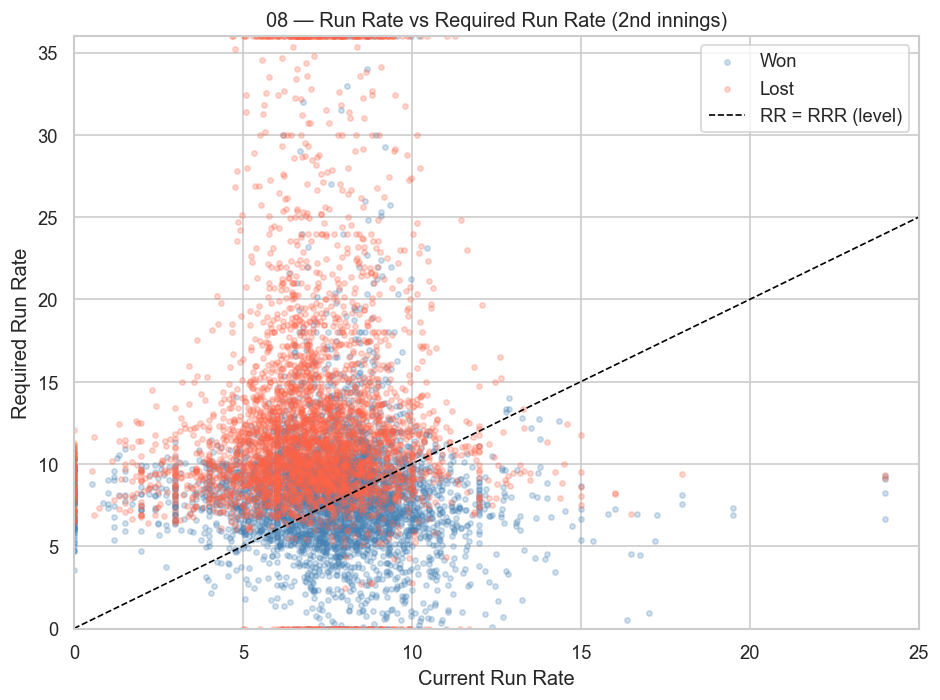

In [13]:
sample = df[df['inning'] == 2].sample(min(8000, len(df[df['inning'] == 2])), random_state=42)
# Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
for won, label, color in [(1, 'Won', 'steelblue'), (0, 'Lost', 'tomato')]:
    sub = sample[sample['batting_team_won'] == won]
    ax.scatter(sub['current_rr'], sub['rrr'], alpha=0.25, s=10, color=color, label=label)
ax.axline((0, 0), slope=1, color='black', lw=1, ls='--', label='RR = RRR (level)')
ax.set_xlim(0, 25); ax.set_ylim(0, 36)
ax.set_xlabel('Current Run Rate')
ax.set_ylabel('Required Run Rate')
ax.set_title('08 — Run Rate vs Required Run Rate (2nd innings)')
ax.legend()
plt.tight_layout()
plt.show()

### Feature Plot — Balls Remaining Distribution per Phase

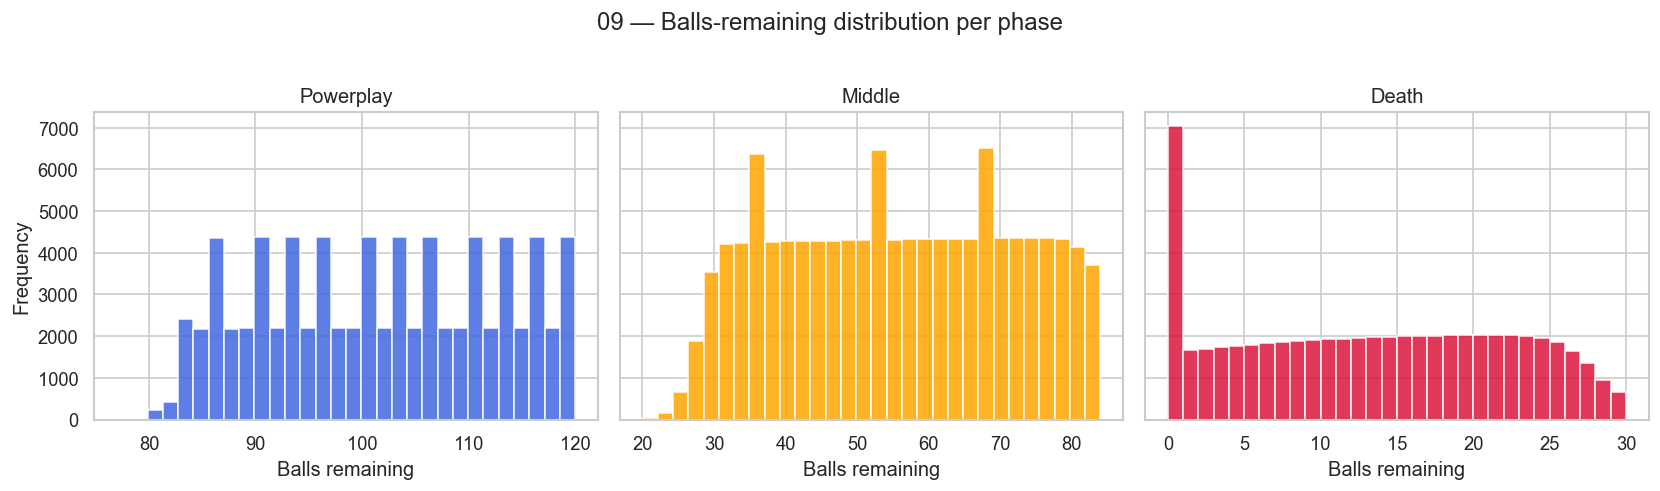

In [14]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
phases = [
    ('is_powerplay', 'Powerplay', 'royalblue'),
    ('is_middle',    'Middle',    'orange'),
    ('is_death',     'Death',     'crimson'),
]
for ax, (col, label, color) in zip(axes, phases):
    sub = df[df[col] == 1]['balls_remaining']
    ax.hist(sub, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label)
    ax.set_xlabel('Balls remaining')
axes[0].set_ylabel('Frequency')
fig.suptitle('09 — Balls-remaining distribution per phase', y=1.02)
plt.tight_layout()
plt.show()

### Feature Plot — Correlation Heatmap (Model Inputs)

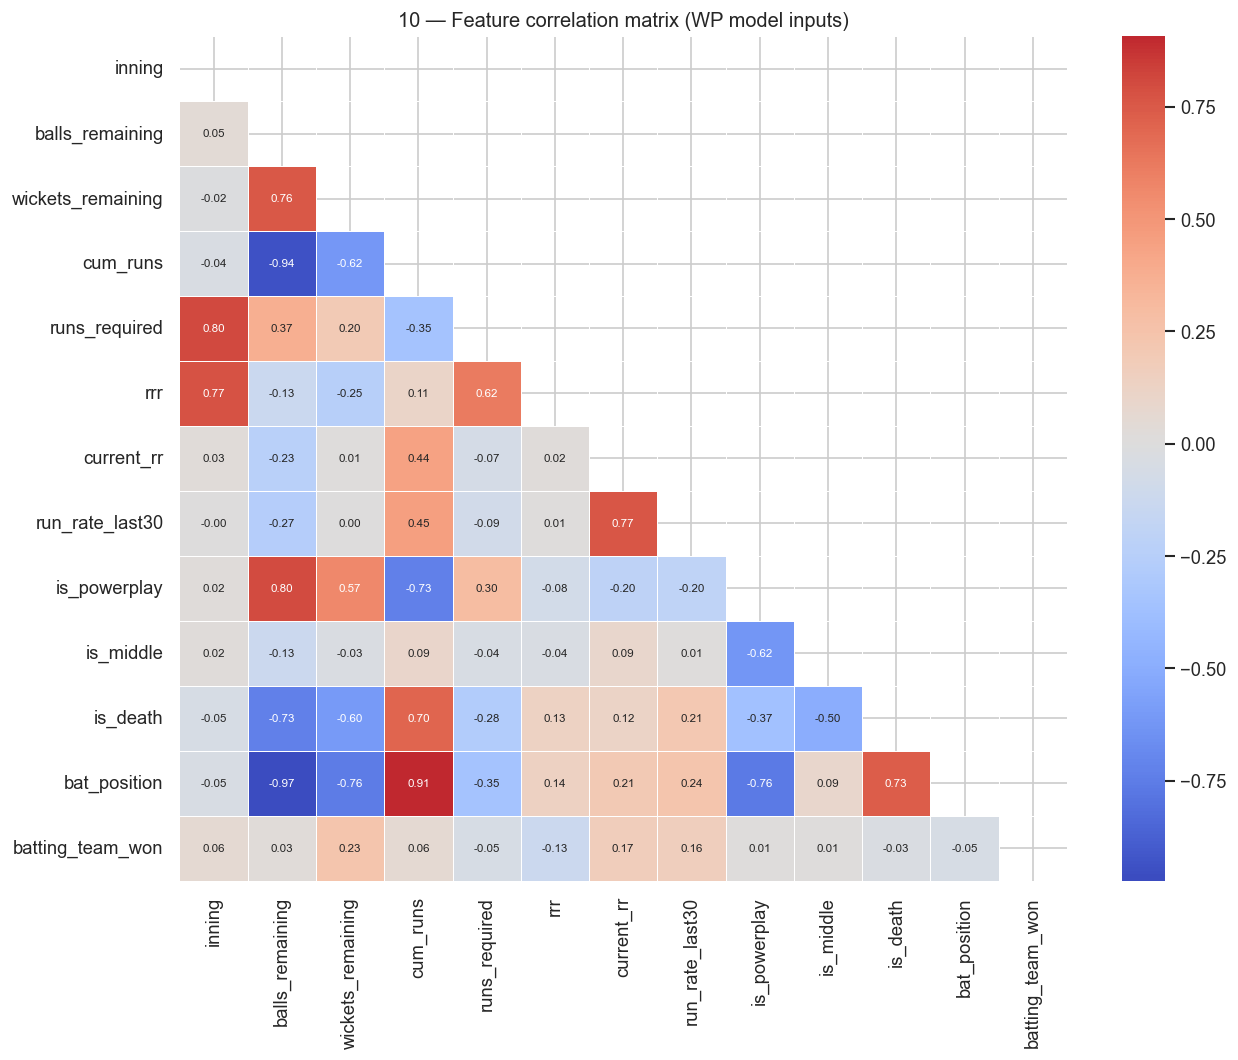

In [15]:
# Visualisation
feat_cols_corr = [
    'inning', 'balls_remaining', 'wickets_remaining',
    'cum_runs', 'runs_required', 'rrr', 'current_rr',
    'run_rate_last30', 'is_powerplay', 'is_middle', 'is_death',
    'bat_position', 'batting_team_won',
]
avail = [c for c in feat_cols_corr if c in df.columns]
corr  = df[avail].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('10 — Feature correlation matrix (WP model inputs)')
plt.tight_layout()
plt.show()

### b) Player-level Aggregate Features

In [16]:
# Batting aggregates
bat = (
    df.groupby('batter').agg(
        balls_faced  = ('batsman_runs', 'count'),
        total_runs   = ('batsman_runs', 'sum'),
        fours        = ('batsman_runs', lambda x: (x == 4).sum()),
        sixes        = ('batsman_runs', lambda x: (x == 6).sum()),
        dismissals   = ('is_wicket',   'sum'),
        pp_runs      = ('batsman_runs',
                        lambda x: x[df.loc[x.index, 'is_powerplay'] == 1].sum()),
        death_runs   = ('batsman_runs',
                        lambda x: x[df.loc[x.index, 'is_death'] == 1].sum()),
    ).reset_index()
)
bat['batting_avg']  = bat['total_runs'] / bat['dismissals'].replace(0, np.nan)
bat['strike_rate']  = bat['total_runs'] / bat['balls_faced'] * 100
bat['boundary_pct'] = (bat['fours'] + bat['sixes']) / bat['balls_faced']
bat = bat.fillna({'batting_avg': bat['total_runs']})

# Bowling aggregates
bowl = (
    df.groupby('bowler').agg(
        balls_bowled  = ('total_runs', 'count'),
        runs_conceded = ('total_runs', 'sum'),
        wickets       = ('is_wicket',  'sum'),
        pp_wickets    = ('is_wicket',
                         lambda x: x[df.loc[x.index, 'is_powerplay'] == 1].sum()),
        death_wickets = ('is_wicket',
                         lambda x: x[df.loc[x.index, 'is_death'] == 1].sum()),
        dot_balls     = ('total_runs', lambda x: (x == 0).sum()),
    ).reset_index()
)
bowl['economy']          = bowl['runs_conceded'] / (bowl['balls_bowled'] / 6)
bowl['bowl_avg']         = bowl['runs_conceded'] / bowl['wickets'].replace(0, np.nan)
bowl['strike_rate_bowl'] = bowl['balls_bowled']  / bowl['wickets'].replace(0, np.nan)
bowl['dot_pct']          = bowl['dot_balls'] / bowl['balls_bowled']
bowl = bowl.fillna({'bowl_avg': 999, 'strike_rate_bowl': 999})

# Wicketkeeper stumpings
stumpings = (
    df[df['dismissal_kind'] == 'stumped']
    .groupby('fielder').size()
    .rename('stumpings').reset_index()
    .rename(columns={'fielder': 'player'})
)

print(f'  Batting records  : {len(bat):,} players')
print(f'  Bowling records  : {len(bowl):,} players')
print(f'  WK candidates    : {len(stumpings):,} players')

player_feats = {'batting': bat, 'bowling': bowl, 'stumpings': stumpings}

  Batting records  : 673 players
  Bowling records  : 530 players
  WK candidates    : 42 players


## Role Classification

In [17]:
def build_player_table(player_feats):
    # Merge batting/bowling/stumpings into one player record.
    _bat   = player_feats['batting'].rename(columns={'batter': 'player'})
    _bowl  = player_feats['bowling'].rename(columns={'bowler': 'player'})
    _stump = player_feats['stumpings']

    players = _bat.merge(
        _bowl[['player', 'balls_bowled', 'wickets', 'economy',
               'bowl_avg', 'strike_rate_bowl', 'dot_pct', 'pp_wickets', 'death_wickets']],
        on='player', how='outer'
    )
    players = players.merge(_stump, on='player', how='left')
    players['balls_faced']  = players['balls_faced'].fillna(0)
    players['balls_bowled'] = players['balls_bowled'].fillna(0)
    players['stumpings']    = players['stumpings'].fillna(0)
    players['strike_rate']  = players['strike_rate'].fillna(0)
    players['economy']      = players['economy'].fillna(99)
    return players


# Stage 1: Hard rules
players = build_player_table(player_feats)
players['role'] = 'Unknown'

is_wk  = players['stumpings'] >= cfg.MIN_STUMPINGS_WK
is_ar  = ((players['balls_faced']  >= cfg.AR_BAT_THRESHOLD) &
          (players['balls_bowled'] >= cfg.AR_BOWL_THRESHOLD))
is_bat = players['balls_faced']  >= cfg.MIN_BALLS_BATSMAN
is_bwl = players['balls_bowled'] >= cfg.MIN_BALLS_BOWLER

# Priority: WK > AR > BWL > BAT
players.loc[is_bat, 'role'] = 'Batsman'
players.loc[is_bwl, 'role'] = 'Bowler'
players.loc[is_ar,  'role'] = 'All-rounder'
players.loc[is_wk,  'role'] = 'Wicketkeeper'

players_stage1 = players.copy()
print('Stage-1: Hard rule distribution:')
print(players['role'].value_counts().to_string())

Stage-1: Hard rule distribution:
role
Unknown         304
Bowler          202
Batsman         100
All-rounder      97
Wicketkeeper     29


### Role Plot — Stage 1 (Hard Rules)

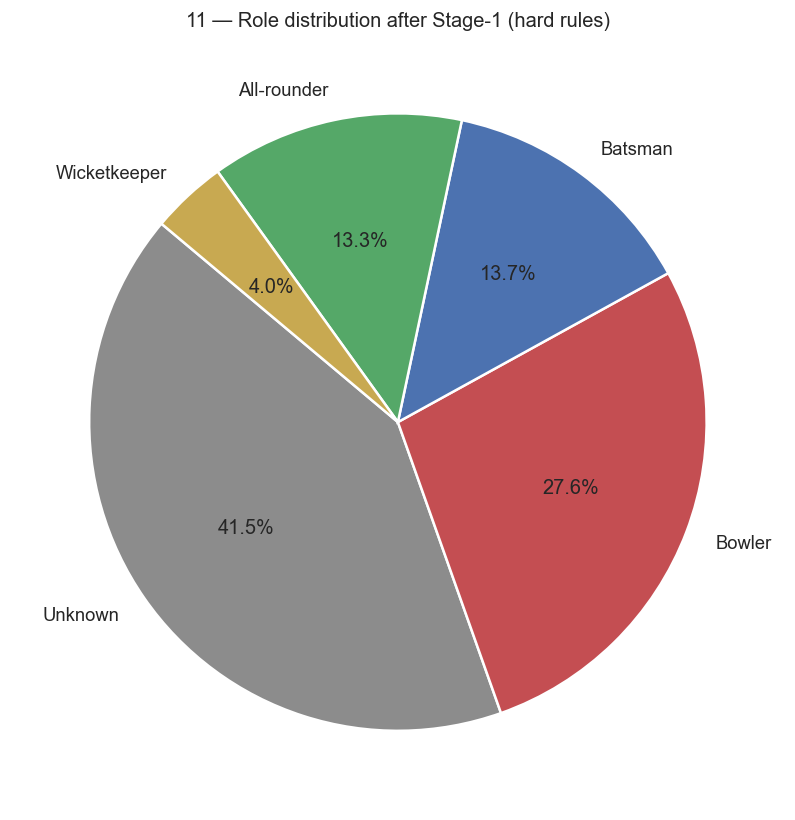

In [18]:
counts = players_stage1['role'].value_counts()
colors = [cfg.ROLE_PALETTE.get(r, '#999') for r in counts.index]
# Visualisation
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts, labels=counts.index, colors=colors, autopct='%1.1f%%',
       startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('11 — Role distribution after Stage-1 (hard rules)')
plt.tight_layout()
plt.show()

In [19]:
# Stage 2: Decision-tree refinement for 'Unknown' players
role_dt = DecisionTreeClassifier(max_depth=6, random_state=cfg.RANDOM_STATE)
feat_cols_role = ['balls_faced', 'balls_bowled', 'strike_rate',
                  'economy', 'boundary_pct', 'dot_pct']

known   = players[players['role'] != 'Unknown']
unknown = players[players['role'] == 'Unknown']

if len(unknown) > 0:
    for c in feat_cols_role:
        if c not in known.columns:
            players[c] = 0
    X_train = known[feat_cols_role].fillna(0)
    y_train = known['role']
    X_unk   = unknown[feat_cols_role].fillna(0)
    role_dt.fit(X_train, y_train)
    players.loc[unknown.index, 'role'] = role_dt.predict(X_unk)
    print(f' Stage-2: DT refined {len(unknown)} Unknown players')
else:
    print('  No Unknown players to refine.')

print('\nFinal role distribution:')
print(players['role'].value_counts().to_string())

 Stage-2: DT refined 304 Unknown players

Final role distribution:
role
Bowler          380
Wicketkeeper    149
Batsman         106
All-rounder      97


### Role Plot — Final (After DT Refinement)

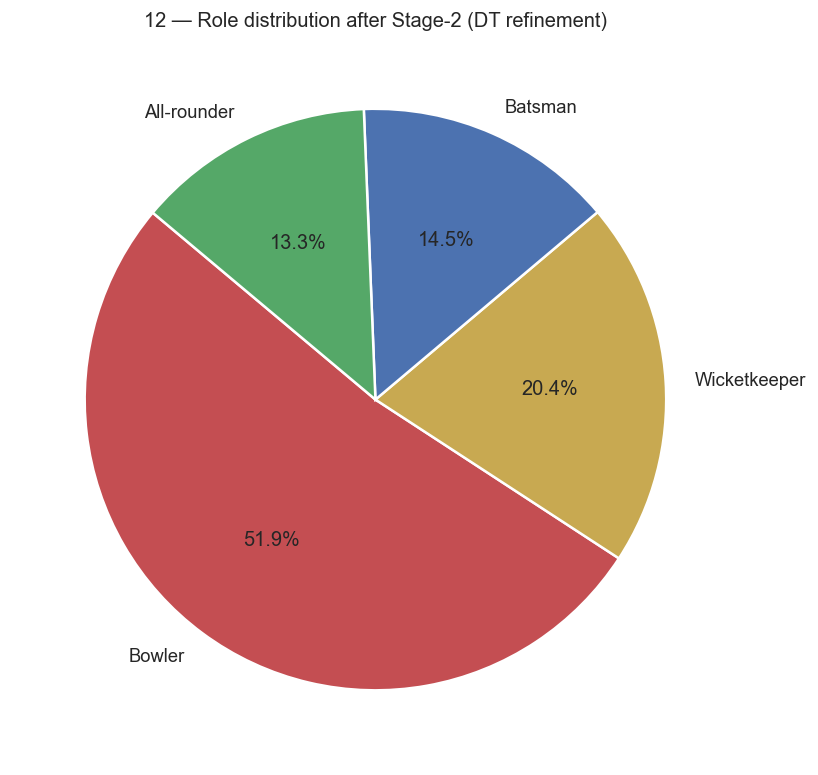

In [20]:
counts_final = players['role'].value_counts()
colors_final = [cfg.ROLE_PALETTE.get(r, '#999') for r in counts_final.index]
# Visualisation
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts_final, labels=counts_final.index, colors=colors_final,
       autopct='%1.1f%%', startangle=140,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('12 — Role distribution after Stage-2 (DT refinement)')
plt.tight_layout()
plt.show()

### Role Plot — Balls Faced vs Bowled (Scatter)

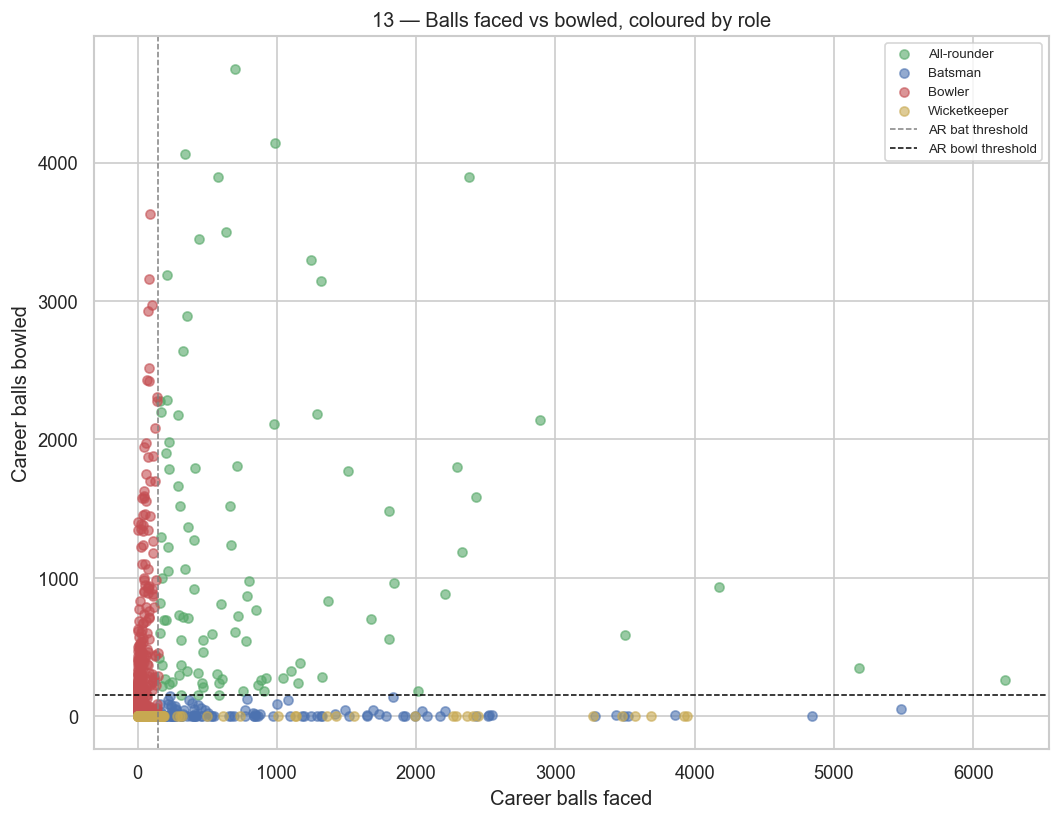

In [21]:
# Visualisation
fig, ax = plt.subplots(figsize=(9, 7))
for role, grp in players.groupby('role'):
    ax.scatter(grp['balls_faced'].fillna(0), grp['balls_bowled'].fillna(0),
               label=role, alpha=0.6, s=30, color=cfg.ROLE_PALETTE.get(role, '#999'))
ax.axvline(cfg.AR_BAT_THRESHOLD,  color='grey',  ls='--', lw=0.9, label='AR bat threshold')
ax.axhline(cfg.AR_BOWL_THRESHOLD, color='black', ls='--', lw=0.9, label='AR bowl threshold')
ax.set_xlabel('Career balls faced')
ax.set_ylabel('Career balls bowled')
ax.set_title('13 — Balls faced vs bowled, coloured by role')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Role Plot — Strike Rate vs Economy

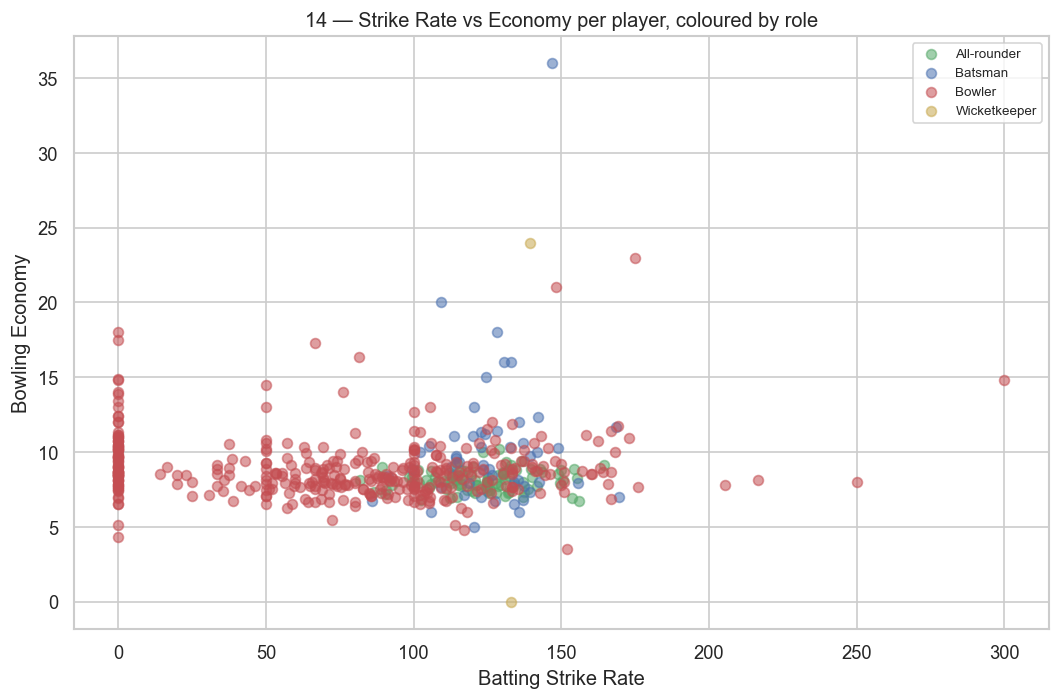

In [22]:
# Visualisation
tmp_role = players[
    players['strike_rate'].notna() & players['economy'].notna() & (players['economy'] < 50)
].copy()

fig, ax = plt.subplots(figsize=(9, 6))
for role, grp in tmp_role.groupby('role'):
    ax.scatter(grp['strike_rate'], grp['economy'],
               label=role, alpha=0.55, s=35, color=cfg.ROLE_PALETTE.get(role, '#999'))
ax.set_xlabel('Batting Strike Rate')
ax.set_ylabel('Bowling Economy')
ax.set_title('14 — Strike Rate vs Economy per player, coloured by role')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Role Plot — Decision Tree Feature Importances

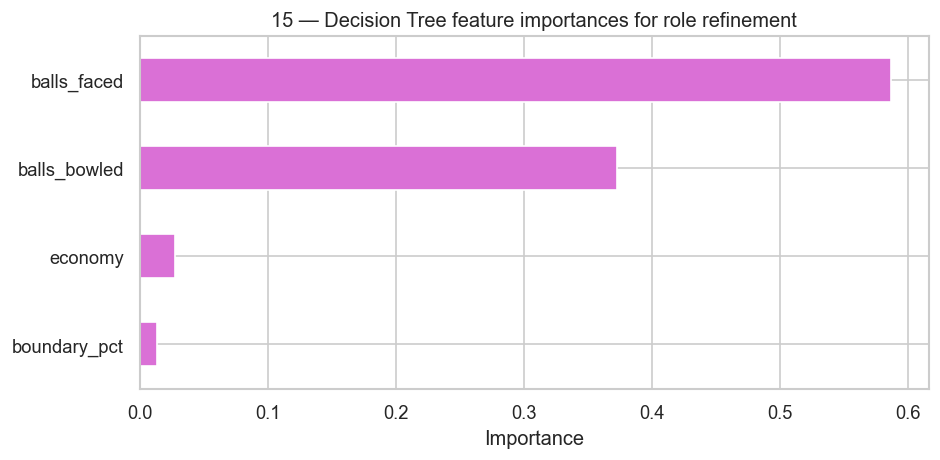

In [23]:
if hasattr(role_dt, 'feature_importances_'):
    imp = pd.Series(role_dt.feature_importances_, index=feat_cols_role)
    imp = imp[imp > 0].sort_values(ascending=True)
    # Visualisation
    fig, ax = plt.subplots(figsize=(8, 4))
    imp.plot(kind='barh', ax=ax, color='orchid', edgecolor='white')
    ax.set_title('15 — Decision Tree feature importances for role refinement')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## Win Probability Model

In [24]:
# Train an XGBoost classifier to estimate P(batting team wins) at every delivery.
WP_FEATURE_COLS = [
    'inning', 'balls_remaining', 'wickets_remaining',
    'cum_runs', 'runs_required', 'rrr', 'current_rr',
    'run_rate_last30', 'is_powerplay', 'is_middle', 'is_death',
    'bat_position',
]

if XGB_AVAILABLE:
    wp_model = XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=cfg.RANDOM_STATE, n_jobs=-1,
    )
    model_name = 'XGBoost'
else:
    wp_model = GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=cfg.RANDOM_STATE,
    )
    model_name = 'GradientBoosting'

print(f'WP Training model: {model_name}')

X = df[WP_FEATURE_COLS].fillna(0).values
y = df['batting_team_won'].values

# Cross-validation on a subsample
n = cfg.WP_SUBSAMPLE
if n and len(X) > n:
    idx = np.random.choice(len(X), n, replace=False)
    Xs, ys = X[idx], y[idx]
else:
    Xs, ys = X, y

cv_auc = cross_val_score(wp_model, Xs, ys,
                          cv=cfg.WP_CV_FOLDS, scoring='roc_auc', n_jobs=-1)
print(f'  Cross-val AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

# Fit on full data
wp_model.fit(X, y)
print('  Model fitted on full dataset.')

WP Training model: GradientBoosting
  Cross-val AUC : 0.7908 ± 0.0021
  Model fitted on full dataset.


### WP Model Plot — Feature Importance

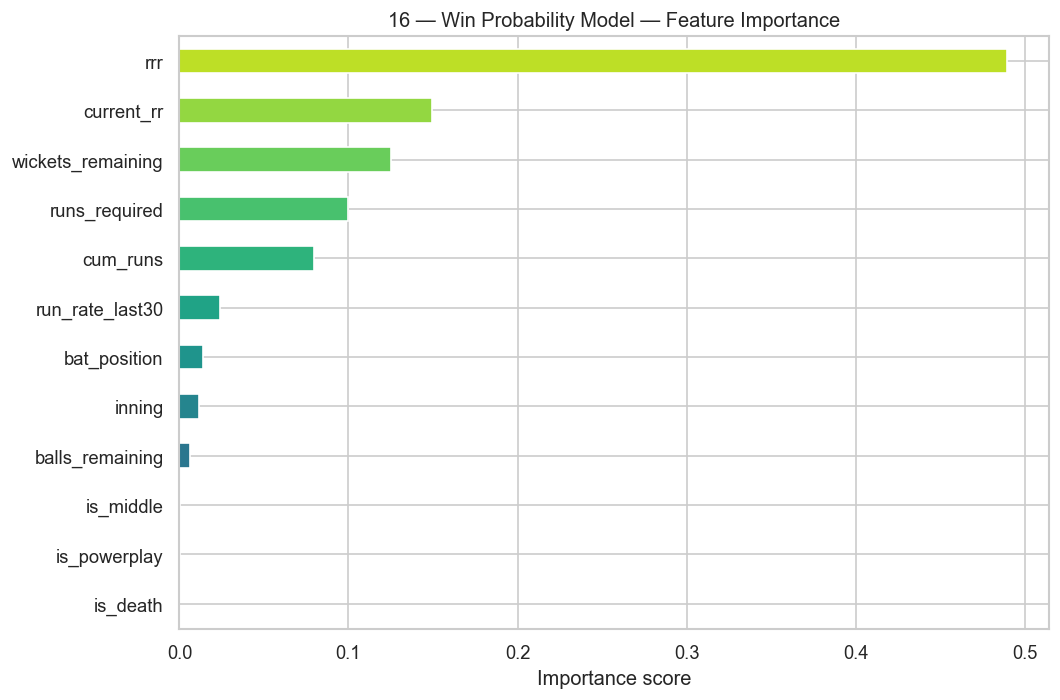

In [25]:
if hasattr(wp_model, 'feature_importances_'):
    imp = pd.Series(wp_model.feature_importances_,
                    index=WP_FEATURE_COLS).sort_values(ascending=True)
    colors_vi = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp)))
    # Visualisation
    fig, ax = plt.subplots(figsize=(9, 6))
    imp.plot(kind='barh', ax=ax, color=colors_vi, edgecolor='white')
    ax.set_title('16 — Win Probability Model — Feature Importance')
    ax.set_xlabel('Importance score')
    plt.tight_layout()
    plt.show()

### WP Model Plot — Calibration Curve

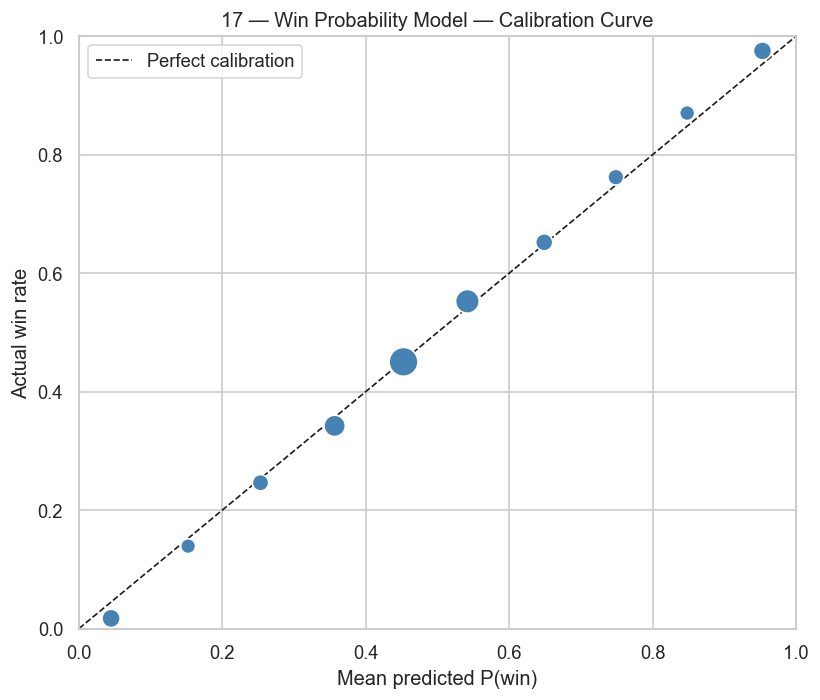

In [26]:
# integrating P(win) to the dataframe
df['pwin_after']  = wp_model.predict_proba(df[WP_FEATURE_COLS].fillna(0).values)[:, 1]
df['pwin_before'] = (
    df.groupby(['match_id', 'inning'])['pwin_after']
      .shift(1).fillna(0.5)
)

cal_df = pd.DataFrame({'pred': df['pwin_after'].values,
                        'actual': df['batting_team_won'].values})
cal_df['bin'] = pd.cut(cal_df['pred'], bins=10)
cal = cal_df.groupby('bin', observed=True).agg(
    pred_mean=('pred', 'mean'),
    actual_mean=('actual', 'mean'),
    count=('actual', 'count'),
).reset_index()
# Visualisation
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cal['pred_mean'], cal['actual_mean'],
           s=cal['count'] / cal['count'].max() * 300,
           color='steelblue', edgecolors='white', zorder=3)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted P(win)')
ax.set_ylabel('Actual win rate')
ax.set_title('17 — Win Probability Model — Calibration Curve')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### WP Model Plot — ROC Curve

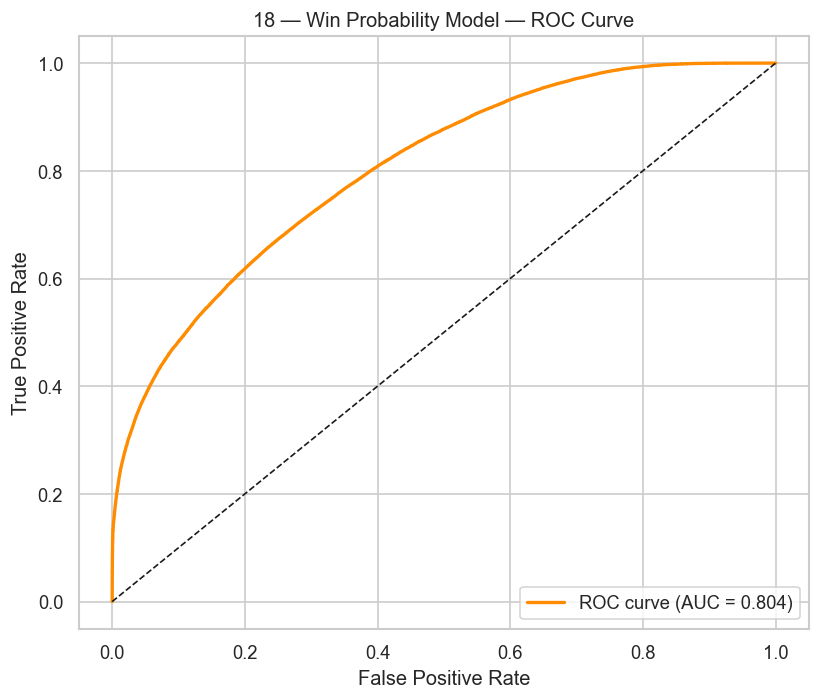

In [27]:
y_true = df['batting_team_won'].values
fpr, tpr, _ = roc_curve(y_true, df['pwin_after'].values)
roc_auc_val = auc(fpr, tpr)
# Visualisation
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('18 — Win Probability Model — ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## WPA & EWR-WPA Calculation

Note : Converts per-delivery P(win) estimates into player value scores with Bayesian shrinkage.

In [28]:
# Raw WPA — batter benefits from rising win prob; bowler benefits from it falling
df['wpa_raw_bat'] =  (df['pwin_after'] - df['pwin_before'])
df['wpa_raw_bow'] = -(df['pwin_after'] - df['pwin_before'])

# Expected WPA per match-state bucket (to compute relative WPA)
df['br_bin'] = pd.cut(df['balls_remaining'], bins=12, labels=False)
df['wr_bin'] = pd.cut(df['wickets_remaining'], bins=5, labels=False)

for side in ('bat', 'bow'):
    raw_col = f'wpa_raw_{side}'
    df[f'wpa_exp_{side}'] = (
        df.groupby(['inning', 'br_bin', 'wr_bin'])[raw_col]
          .transform('mean').fillna(0.0)
    )
    df[f'rwpa_{side}'] = df[raw_col] - df[f'wpa_exp_{side}']

# Phase labels
df['phase'] = np.select(
    [df['is_powerplay'] == 1, df['is_middle'] == 1, df['is_death'] == 1],
    ['powerplay', 'middle', 'death'],
    default='middle'
)


def aggregate_scores(id_col, side):
    rwpa_col = f'rwpa_{side}'
    k        = cfg.EVIDENCE_K
    career = (
        df.groupby(id_col).agg(
            total_rwpa   = (rwpa_col, 'sum'),
            n_deliveries = (rwpa_col, 'count'),
        ).reset_index()
    )
    career['ewr_wpa'] = (
        career['total_rwpa'] * career['n_deliveries'] / (career['n_deliveries'] + k)
    )
    phase_pivot = (
        df.groupby([id_col, 'phase'])[rwpa_col]
          .sum().unstack(fill_value=0.0)
          .rename(columns=lambda p: f'rwpa_{p}')
          .reset_index()
    )
    for ph in ['powerplay', 'middle', 'death']:
        col = f'rwpa_{ph}'
        if col not in phase_pivot.columns:
            phase_pivot[col] = 0.0
    scores = career.merge(phase_pivot, on=id_col, how='left')
    scores = scores.rename(columns={id_col: 'player'})
    return scores.sort_values('ewr_wpa', ascending=False).reset_index(drop=True)


bat_scores = aggregate_scores('batter', 'bat')
bow_scores = aggregate_scores('bowler', 'bow')

print(f'  Batter scores computed : {len(bat_scores):,} players')
print(f'  Bowler scores computed : {len(bow_scores):,} players')

  Batter scores computed : 673 players
  Bowler scores computed : 530 players


### WPA Plot — Raw WPA Distribution (Batting)

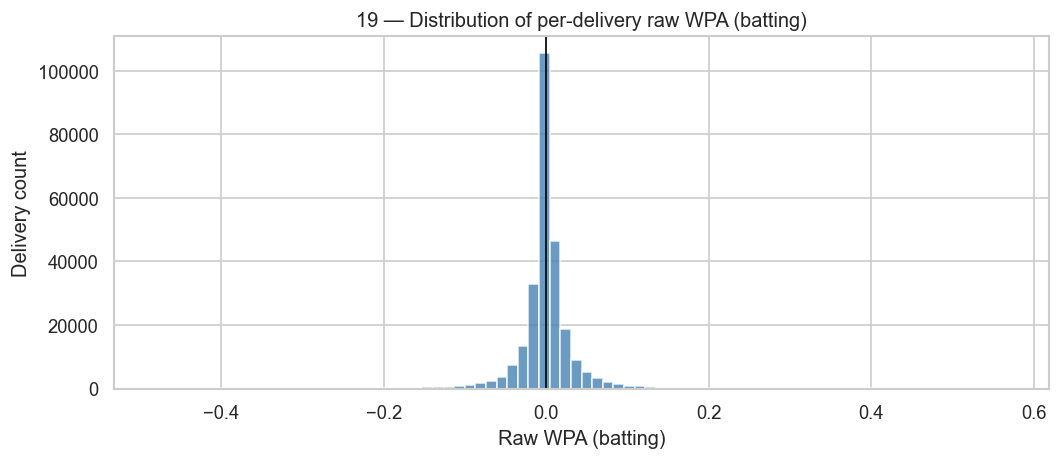

In [29]:
# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['wpa_raw_bat'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Raw WPA (batting)')
ax.set_ylabel('Delivery count')
ax.set_title('19 — Distribution of per-delivery raw WPA (batting)')
plt.tight_layout()
plt.show()

### WPA Plot — Raw WPA Distribution (Bowling)

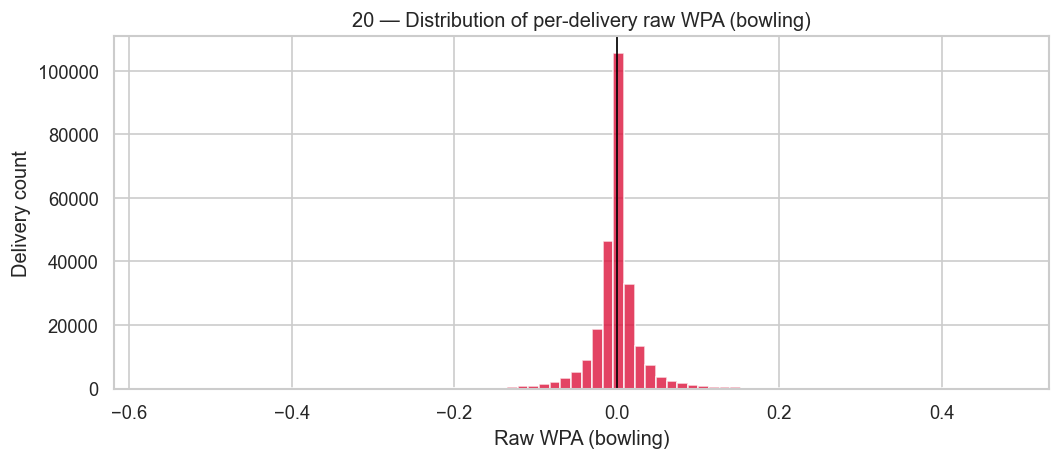

In [30]:
# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['wpa_raw_bow'].dropna(), bins=80, color='crimson', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Raw WPA (bowling)')
ax.set_ylabel('Delivery count')
ax.set_title('20 — Distribution of per-delivery raw WPA (bowling)')
plt.tight_layout()
plt.show()

### WPA Plot — Top 20 Batters by EWR-WPA

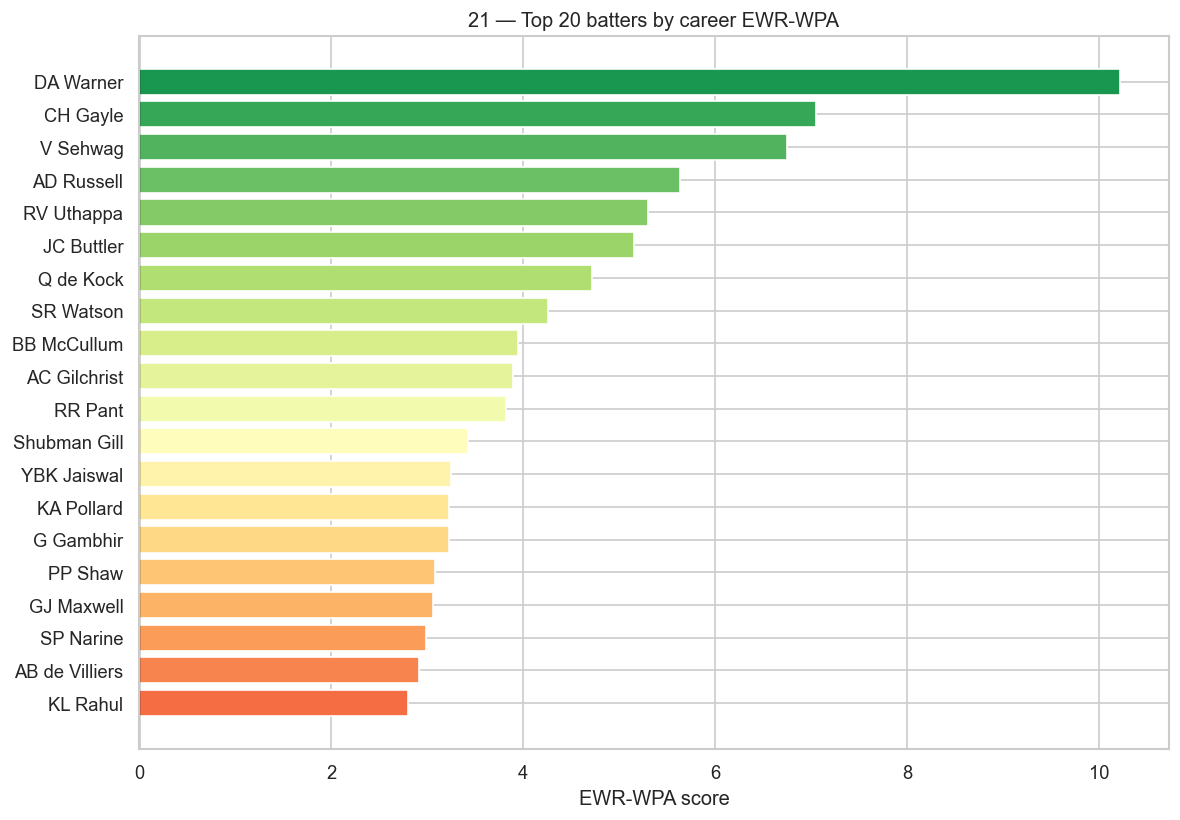

In [31]:
top_bat = bat_scores.nlargest(20, 'ewr_wpa')
colors_bat = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_bat)))[::-1]
# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_bat['player'], top_bat['ewr_wpa'], color=colors_bat, edgecolor='white')
ax.set_xlabel('EWR-WPA score')
ax.set_title('21 — Top 20 batters by career EWR-WPA')
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

### WPA Plot — Top 20 Bowlers by EWR-WPA

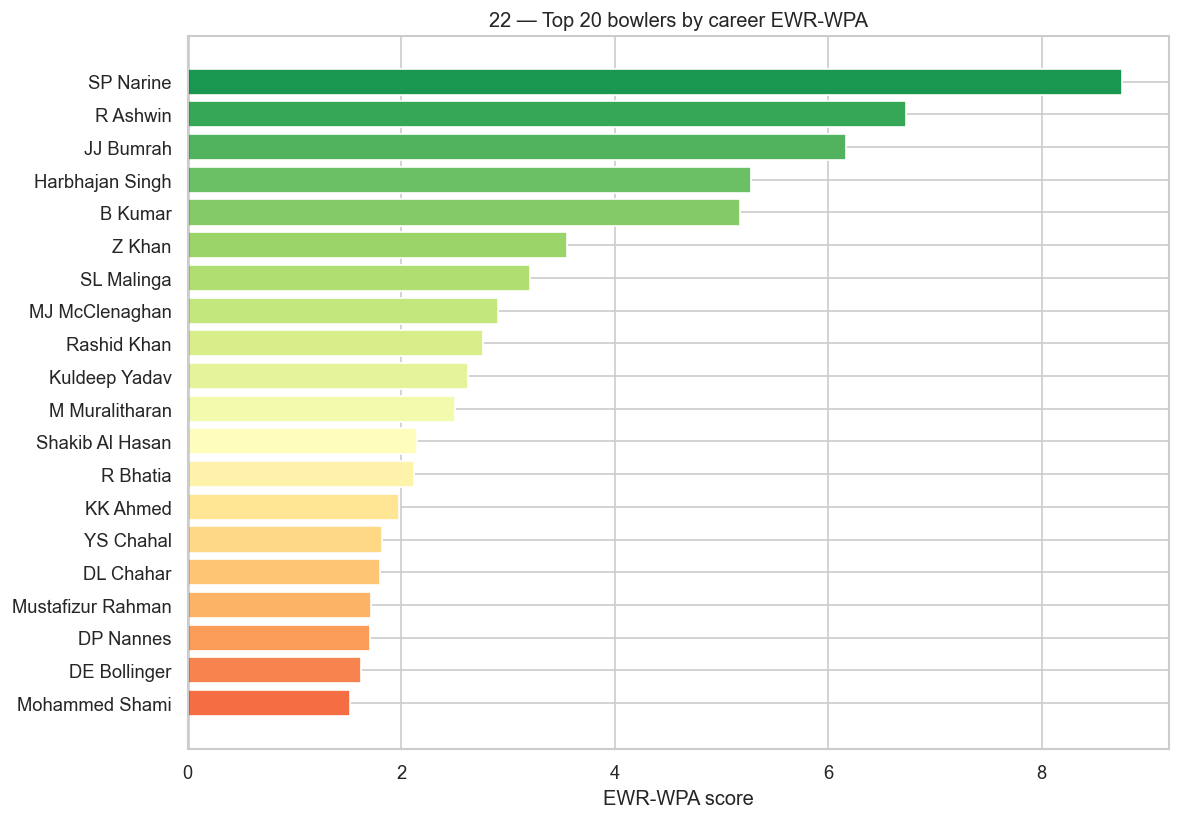

In [32]:
top_bow = bow_scores.nlargest(20, 'ewr_wpa')
colors_bow = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_bow)))[::-1]
# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_bow['player'], top_bow['ewr_wpa'], color=colors_bow, edgecolor='white')
ax.set_xlabel('EWR-WPA score')
ax.set_title('22 — Top 20 bowlers by career EWR-WPA')
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

### WPA Plot — Phase R-WPA for Top 20 Batters

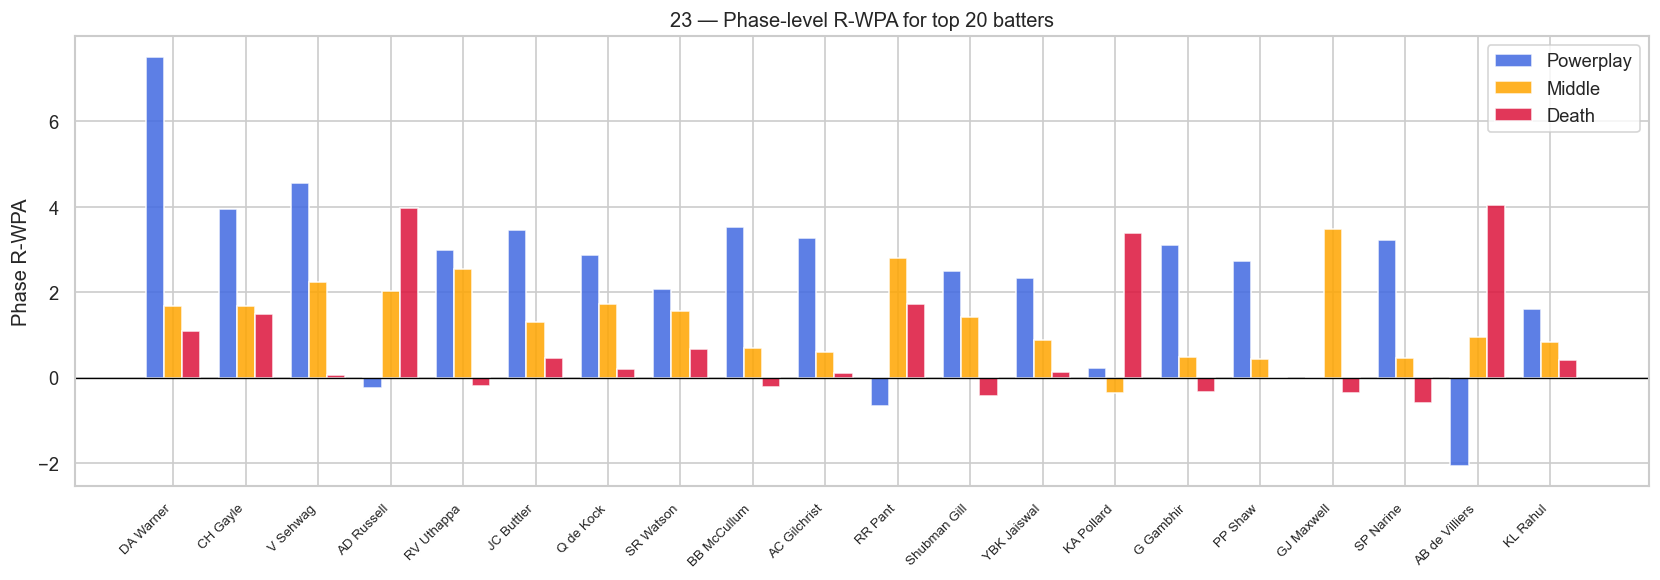

In [33]:
def plot_phase_stack(scores, id_label, chart_num):
    top   = scores.nlargest(20, 'ewr_wpa')
    avail = [c for c in ['rwpa_powerplay', 'rwpa_middle', 'rwpa_death'] if c in top.columns]
    if not avail:
        print('No phase columns available.')
        return
    labels = [c.replace('rwpa_', '').title() for c in avail]
    x      = np.arange(len(top))
    width  = 0.25
    colors = ['royalblue', 'orange', 'crimson']
    # Visualisation
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (col, color, label) in enumerate(zip(avail, colors, labels)):
        ax.bar(x + i * width, top[col].fillna(0), width,
               label=label, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(top['player'], rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('Phase R-WPA')
    ax.set_title(f'{chart_num} — Phase-level R-WPA for top 20 {id_label}s')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_phase_stack(bat_scores, 'batter', '23')

### WPA Plot — Phase R-WPA for Top 20 Bowlers

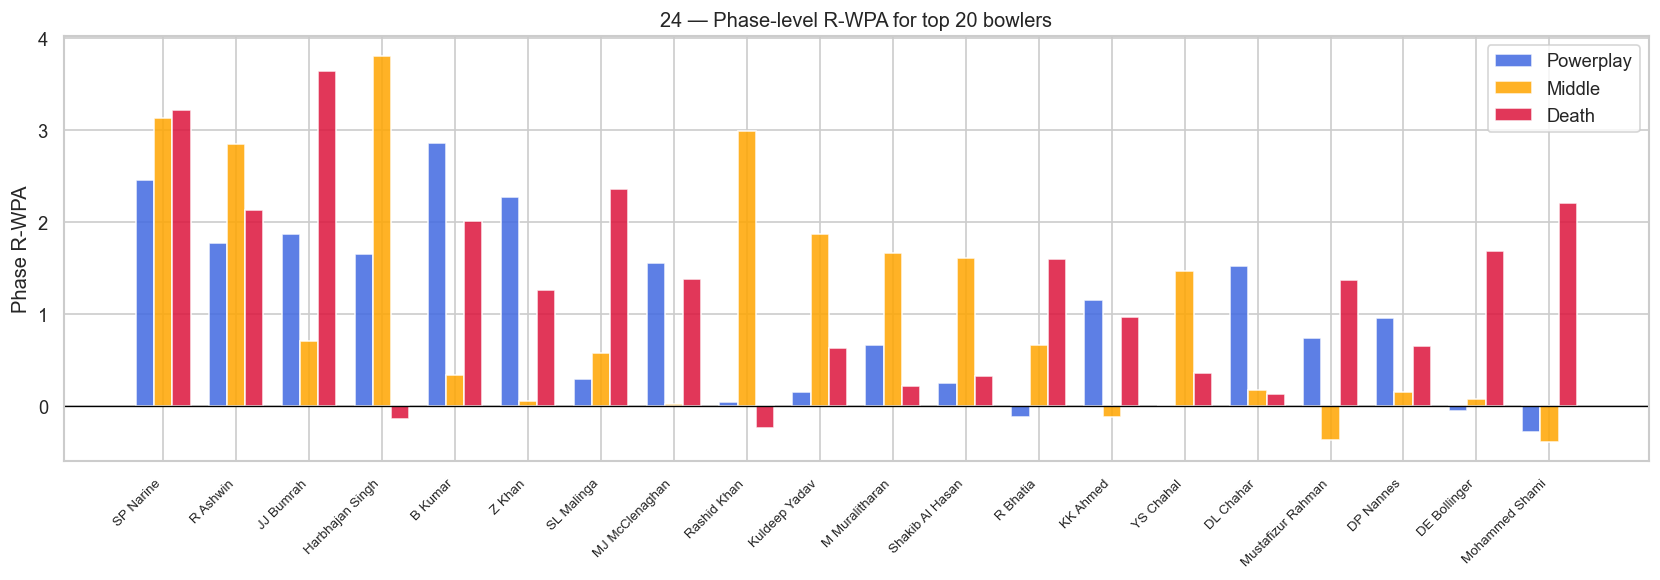

In [34]:
# Visualisation
plot_phase_stack(bow_scores, 'bowler', '24')

## Franchise Player Pool

In [35]:
# Filtering players who appeared for the target franchise
franchise = cfg.FRANCHISE_NAME
print(f'Building player pool for "{franchise}" ')

# Validate franchise name
known_teams = set(df['batting_team'].unique()) | set(df['bowling_team'].unique())
if franchise not in known_teams:
    raise ValueError(
        f"Franchise '{franchise}' not found.\n"
        f"Available teams: {sorted(known_teams)}\n"
        "Check Config.FRANCHISE_NAME and Config.FRANCHISE_ALIASES."
    )

# All players who batted / bowled for the franchise
bat_for = df[df['batting_team'] == franchise]['batter'].unique()
bow_for = df[df['bowling_team'] == franchise]['bowler'].unique()
franchise_players = set(bat_for) | set(bow_for)
print(f'  Total players ever fielded : {len(franchise_players):,}')

# Recency: last N seasons 
all_seasons    = sorted(matches['season'].unique())
recent_seasons = set(all_seasons[-cfg.RECENT_N_SEASONS:])
recent_matches = matches[matches['season'].isin(recent_seasons)]['id']
df_recent      = df[df['match_id'].isin(recent_matches)]
recent_bat     = df_recent[df_recent['batting_team'] == franchise]['batter'].unique()
recent_bow     = df_recent[df_recent['bowling_team'] == franchise]['bowler'].unique()
recent_players = set(recent_bat) | set(recent_bow)
print(f'  In last {cfg.RECENT_N_SEASONS} seasons     : {len(recent_players):,}')

# Franchise-specific stats
df_bat_fran = df[df['batting_team'] == franchise]
df_bow_fran = df[df['bowling_team'] == franchise]

fran_bat = (
    df_bat_fran.groupby('batter').agg(
        fran_runs        = ('batsman_runs', 'sum'),
        fran_balls_faced = ('batsman_runs', 'count'),
        fran_sr          = ('batsman_runs', lambda x: x.sum() / len(x) * 100),
    ).reset_index().rename(columns={'batter': 'player'})
)
fran_bow = (
    df_bow_fran.groupby('bowler').agg(
        fran_wickets      = ('is_wicket', 'sum'),
        fran_balls_bowled = ('is_wicket', 'count'),
        fran_economy      = ('total_runs', lambda x: x.sum() / (len(x) / 6)),
    ).reset_index().rename(columns={'bowler': 'player'})
)

# Merge everything
pool = players[players['player'].isin(franchise_players)].copy()
pool = pool.merge(bat_scores[['player', 'ewr_wpa',
                               'rwpa_powerplay', 'rwpa_middle', 'rwpa_death']],
                  on='player', how='left', suffixes=('', '_bat'))
pool = pool.merge(bow_scores[['player', 'ewr_wpa',
                               'rwpa_powerplay', 'rwpa_middle', 'rwpa_death']],
                  on='player', how='left', suffixes=('_bat', '_bow'))
pool = pool.merge(fran_bat, on='player', how='left')
pool = pool.merge(fran_bow, on='player', how='left')

# Combined EWR-WPA by role
pool['combined_ewr_wpa'] = np.where(
    pool['role'] == 'Batsman',     pool['ewr_wpa_bat'].fillna(0),
    np.where(
        pool['role'] == 'Bowler',  pool['ewr_wpa_bow'].fillna(0),
        np.where(
            pool['role'].isin(['All-rounder', 'Wicketkeeper']),
            (pool['ewr_wpa_bat'].fillna(0) + pool['ewr_wpa_bow'].fillna(0)) / 2,
            0
        )
    )
)

# Recency bonus (+10%)
pool['recency_bonus']   = pool['player'].isin(recent_players).astype(float) * 0.10
pool['final_score']     = pool['combined_ewr_wpa'] * (1 + pool['recency_bonus'])
pool['in_recent_squad'] = pool['player'].isin(recent_players)
pool = pool.fillna(0)


print(f'  Pool size after merge : {len(pool):,}')

Building player pool for "Mumbai Indians" 
  Total players ever fielded : 148
  In last 4 seasons     : 57
  Pool size after merge : 148


### Pool Plot — Role Donut

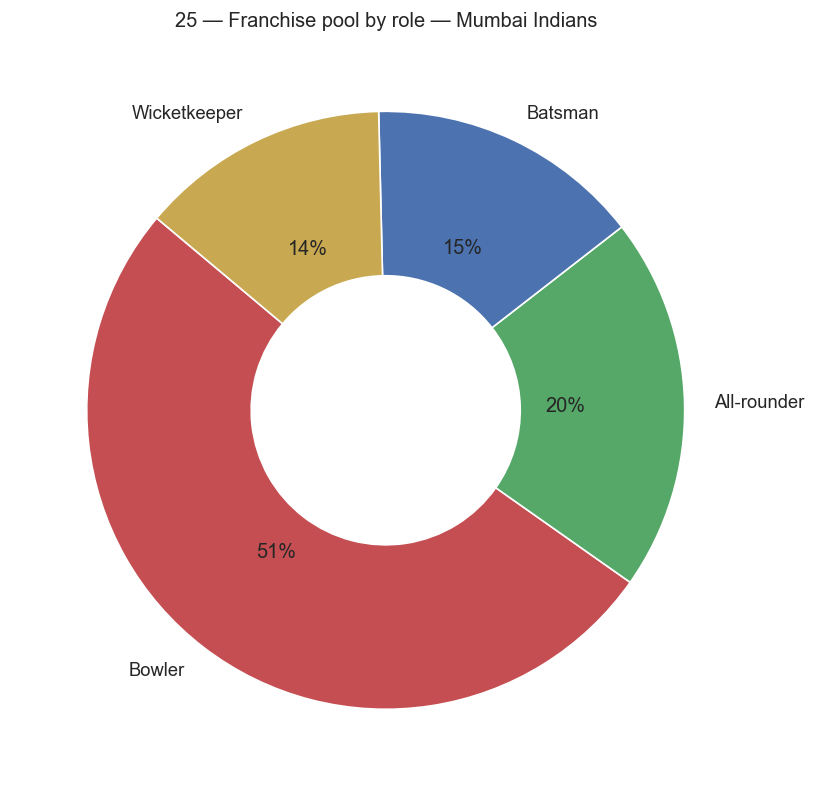

In [36]:
# Visualisation
counts_pool = pool['role'].value_counts()
colors_pool = [cfg.ROLE_PALETTE.get(r, '#999') for r in counts_pool.index]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts_pool, labels=counts_pool.index, colors=colors_pool,
       autopct='%1.0f%%', startangle=140,
       wedgeprops=dict(width=0.55, edgecolor='white'))
ax.set_title(f'25 — Franchise pool by role — {franchise}')
plt.tight_layout()
plt.show()

### Pool Plot — Recent vs Historical Players

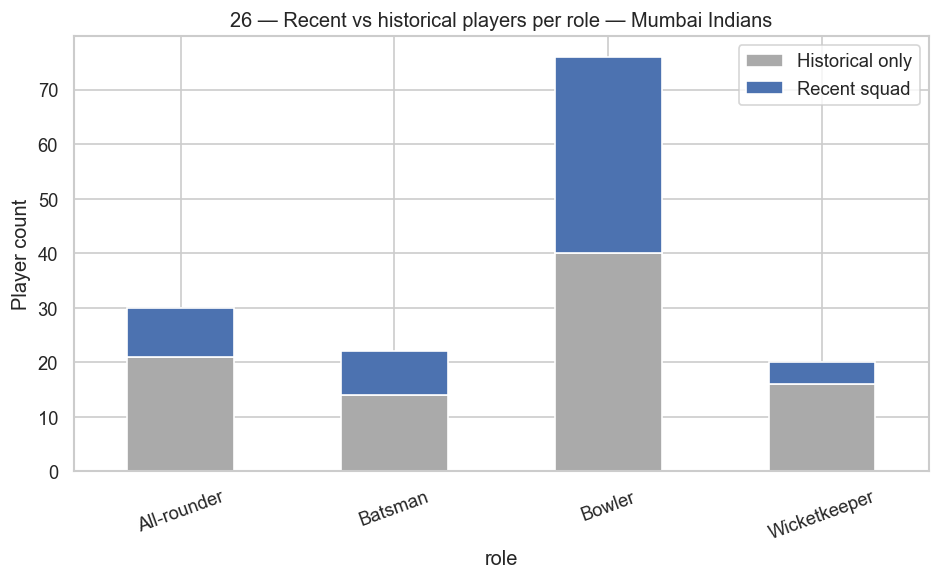

In [37]:
pool_recency = pool.groupby(['role', 'in_recent_squad']).size().unstack(fill_value=0)
pool_recency.columns = ['Historical only', 'Recent squad']
# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
pool_recency.plot(kind='bar', ax=ax, stacked=True,
                  color=['#AAAAAA', '#4C72B0'], edgecolor='white')
ax.set_title(f'26 — Recent vs historical players per role — {franchise}')
ax.set_ylabel('Player count')
plt.xticks(rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

### Pool Plot — Final Score Distribution per Role

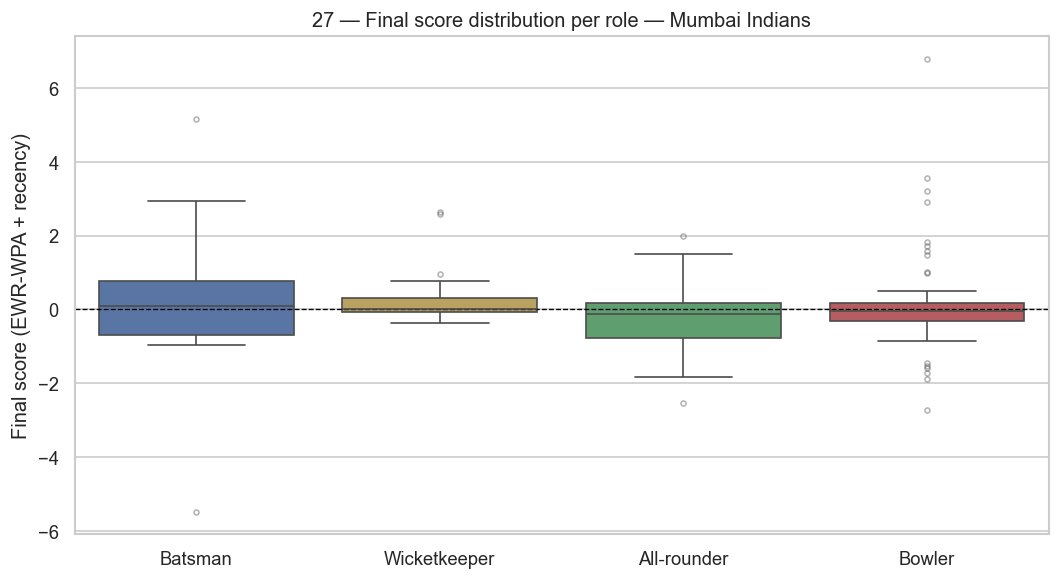

In [38]:
order_roles = [r for r in ['Batsman', 'Wicketkeeper', 'All-rounder', 'Bowler']
               if r in pool['role'].unique()]
palette_pool = {r: cfg.ROLE_PALETTE.get(r, '#999') for r in order_roles}
# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=pool, x='role', y='final_score',
            order=order_roles, palette=palette_pool, ax=ax,
            flierprops=dict(marker='o', ms=3, alpha=0.4))
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title(f'27 — Final score distribution per role — {franchise}')
ax.set_xlabel('')
ax.set_ylabel('Final score (EWR-WPA + recency)')
plt.tight_layout()
plt.show()

## Playing XI Selection
Note: Constraint-based greedy selection: 4 Batsmen · 1 WK · 3 All-rounders · 3 Bowlers

In [39]:
# Normalise role names
role_normalise = {
    'batsman': 'Batsman', 'bat': 'Batsman',
    'wicketkeeper': 'Wicketkeeper', 'wk': 'Wicketkeeper',
    'wicket-keeper': 'Wicketkeeper', 'wicket keeper': 'Wicketkeeper',
    'all-rounder': 'All-rounder', 'allrounder': 'All-rounder', 'all rounder': 'All-rounder',
    'bowler': 'Bowler', 'bowl': 'Bowler',
}
pool['role'] = pool['role'].str.strip().map(
    lambda r: role_normalise.get(str(r).lower(), r)
)

composition = {
    'Batsman'     : cfg.XI_BATSMEN,
    'Wicketkeeper': cfg.XI_WK,
    'All-rounder' : cfg.XI_ALLROUNDERS,
    'Bowler'      : cfg.XI_BOWLERS,
}

selected, used = [], set()

for role, n_slots in composition.items():
    candidates = pool[(pool['role'] == role) & (~pool['player'].isin(used))].copy()

    if len(candidates) == 0:
        print(f'  No candidates for "{role}" — using best remaining players.')
        candidates = pool[~pool['player'].isin(used)].copy()

    # Role-specific tie-breaking
    if role == 'Batsman':
        candidates = candidates.sort_values(['final_score', 'fran_sr'], ascending=[False, False])
    elif role == 'Wicketkeeper':
        candidates = candidates.sort_values(['final_score', 'stumpings'], ascending=[False, False])
    elif role == 'All-rounder':
        candidates = candidates.sort_values(['final_score', 'combined_ewr_wpa'], ascending=[False, False])
    elif role == 'Bowler':
        candidates = candidates.sort_values(['final_score', 'fran_economy'], ascending=[False, True])

    picks = candidates.head(n_slots)
    used.update(picks['player'].tolist())
    selected.append(picks)

xi = pd.concat(selected, ignore_index=True)

# Sort by batting order proxy
role_order = {'Batsman': 1, 'Wicketkeeper': 2, 'All-rounder': 3, 'Bowler': 4}
xi['role_order'] = xi['role'].map(role_order)
xi = xi.sort_values(['role_order', 'final_score'], ascending=[True, False]).reset_index(drop=True)
xi.index += 1

print(f'Selecting Playing XI for "{franchise}"')
# Print the XI
print(f"      Playing XI  –  {franchise:<35} ")
print(f"  {'─'*70}")
print(f"  {'#':<4} {'Player':<25} {'Role':<16} {'EWR-WPA':>8}  {'Score':>8}")
print(f"  {'─'*70}")
for i, row in xi.iterrows():
    print(f"  {i:<4} {row['player']:<25} {row['role']:<16} "
          f"{row['combined_ewr_wpa']:>8.2f}  {row['final_score']:>8.2f}")
print(f"  {'─'*70}")

Selecting Playing XI for "Mumbai Indians"
      Playing XI  –  Mumbai Indians                      
  ──────────────────────────────────────────────────────────────────────
  #    Player                    Role              EWR-WPA     Score
  ──────────────────────────────────────────────────────────────────────
  1    JC Buttler                Batsman              5.15      5.15
  2    Tilak Varma               Batsman              2.68      2.95
  3    MEK Hussey                Batsman              2.60      2.60
  4    S Dhawan                  Batsman              2.53      2.53
  5    RV Uthappa                Wicketkeeper         2.65      2.65
  6    GJ Maxwell                All-rounder          2.00      2.00
  7    Harbhajan Singh           All-rounder          1.51      1.51
  8    KA Pollard                All-rounder          1.20      1.32
  9    JJ Bumrah                 Bowler               6.17      6.78
  10   Z Khan                    Bowler               3.56      

### XI Plot — Final Score Bar Chart

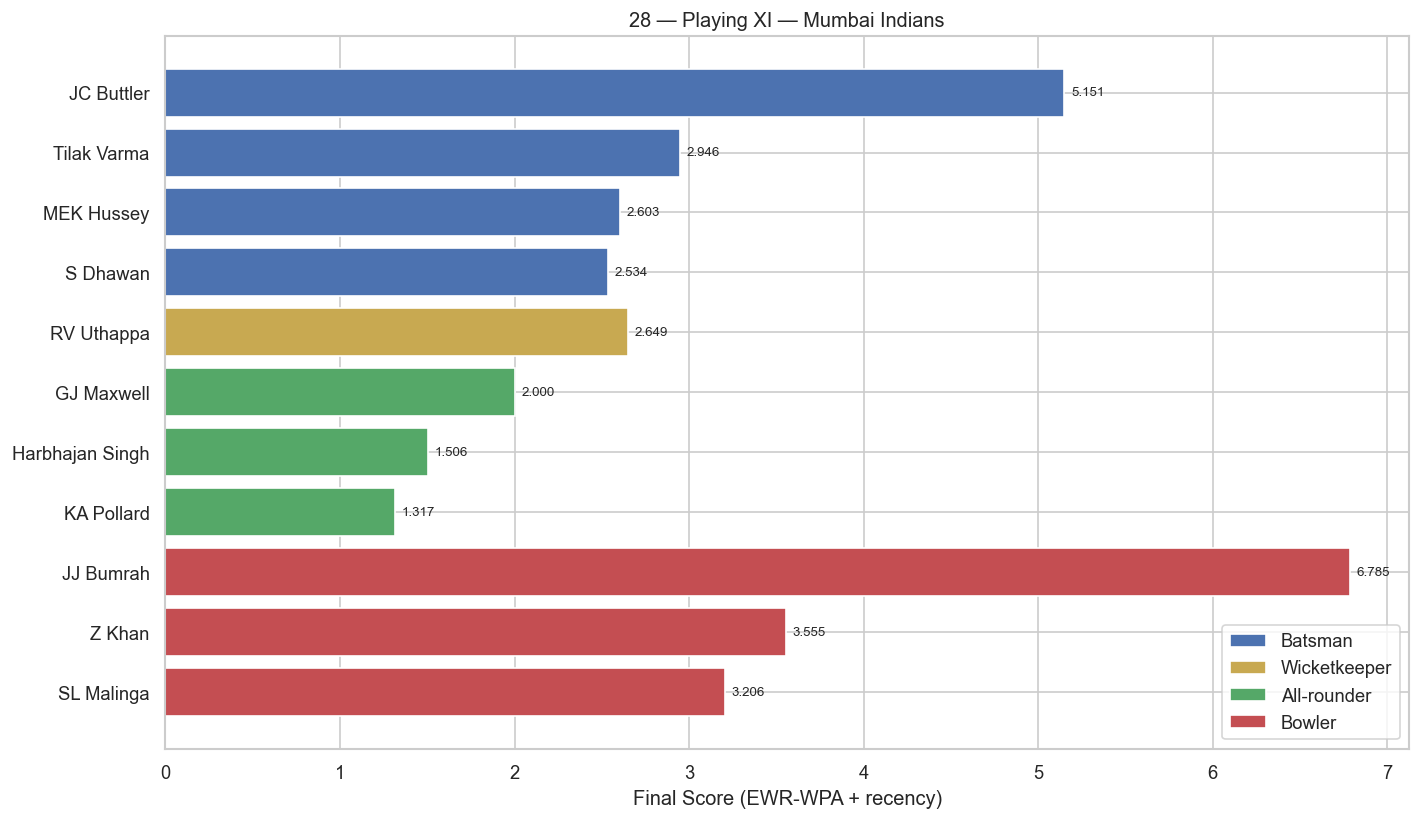

In [40]:
xi_colors = xi['role'].map(lambda r: cfg.ROLE_PALETTE.get(r, '#999'))
# Visualisation
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(xi['player'], xi['final_score'], color=xi_colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=8)
ax.set_xlabel('Final Score (EWR-WPA + recency)')
ax.set_title(f'28 — Playing XI — {franchise}')
ax.invert_yaxis()
legend_el = [Patch(facecolor=c, label=r) for r, c in cfg.ROLE_PALETTE.items()
             if r in xi['role'].values]
ax.legend(handles=legend_el, loc='lower right')
plt.tight_layout()
plt.show()

### XI Plot — Phase R-WPA Heatmap

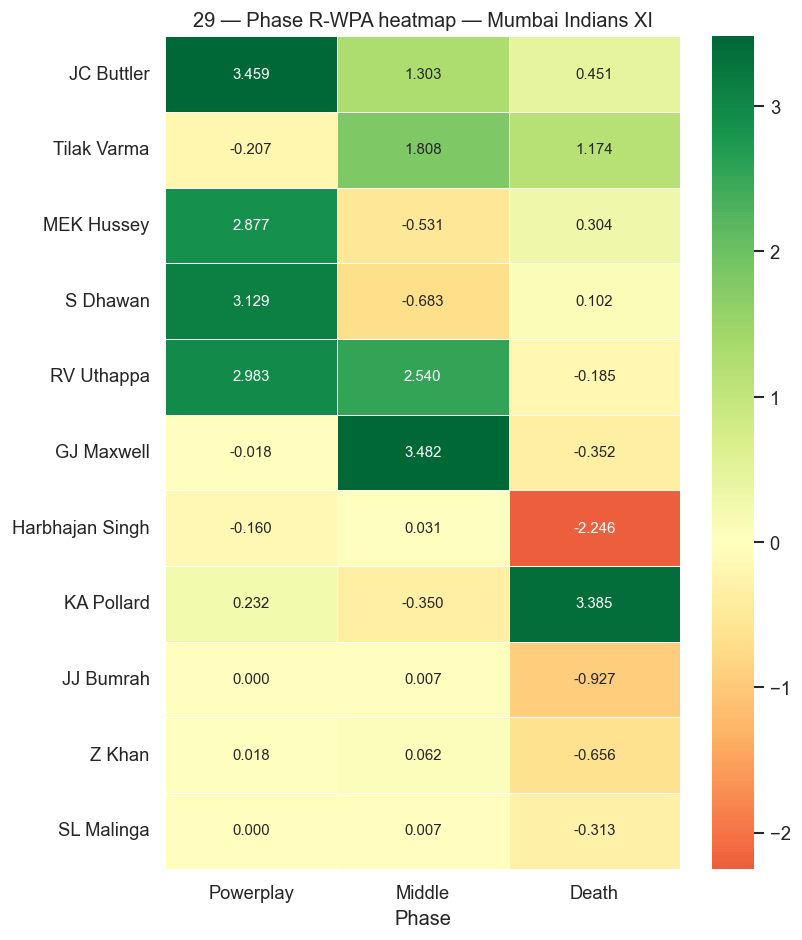

In [41]:
pp_col  = next((c for c in ['rwpa_powerplay_bat', 'rwpa_powerplay'] if c in xi.columns), None)
mid_col = next((c for c in ['rwpa_middle_bat',    'rwpa_middle']    if c in xi.columns), None)
dth_col = next((c for c in ['rwpa_death_bat',     'rwpa_death']     if c in xi.columns), None)
phase_cols = [c for c in [pp_col, mid_col, dth_col] if c]
# Visualisation
if phase_cols:
    heat = xi.set_index('player')[phase_cols].fillna(0)
    heat.columns = ['Powerplay', 'Middle', 'Death'][:len(phase_cols)]

    fig, ax = plt.subplots(figsize=(7, 8))
    sns.heatmap(heat, annot=True, fmt='.3f', cmap='RdYlGn',
                center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
    ax.set_title(f'29 — Phase R-WPA heatmap — {franchise} XI')
    ax.set_xlabel('Phase')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

## Final Analysis

### Batting Profile — XI Batters, All-rounders & WK

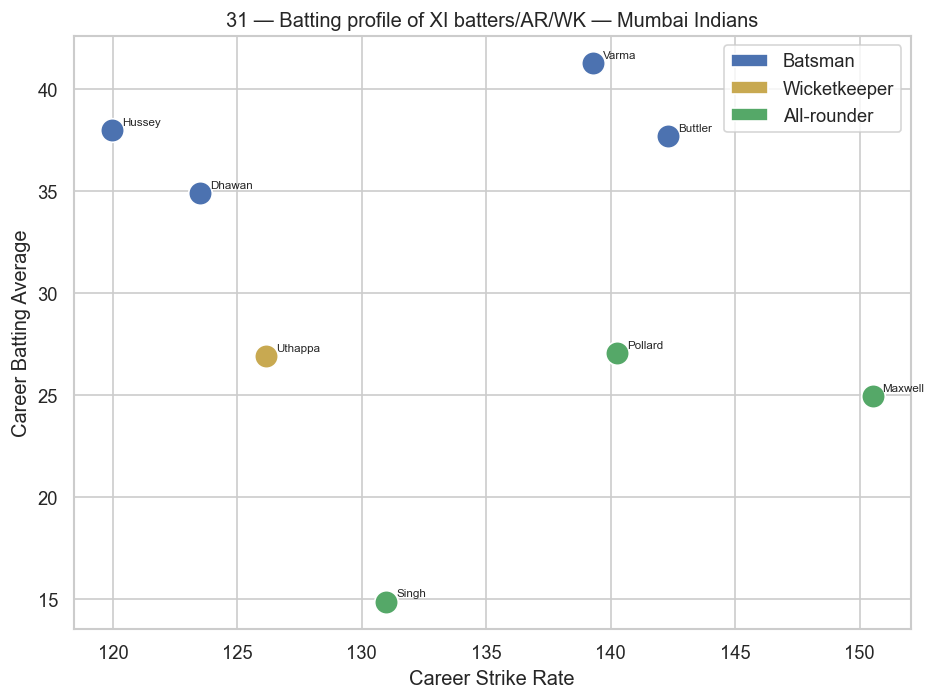

In [42]:
bat_roles = ['Batsman', 'Wicketkeeper', 'All-rounder']
sub_bat   = xi[xi['role'].isin(bat_roles)].copy()

# Visualisation
if not sub_bat.empty and 'strike_rate' in sub_bat.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in sub_bat.iterrows():
        ax.scatter(row.get('strike_rate', 0), row.get('batting_avg', 0),
                   s=200, color=cfg.ROLE_PALETTE.get(row['role'], '#999'),
                   zorder=3, edgecolors='white')
        ax.annotate(row['player'].split()[-1],
                    (row.get('strike_rate', 0), row.get('batting_avg', 0)),
                    textcoords='offset points', xytext=(6, 3), fontsize=7)
    ax.set_xlabel('Career Strike Rate')
    ax.set_ylabel('Career Batting Average')
    ax.set_title(f'31 — Batting profile of XI batters/AR/WK — {franchise}')
    leg = [Patch(facecolor=cfg.ROLE_PALETTE.get(r, '#999'), label=r)
           for r in sub_bat['role'].unique()]
    ax.legend(handles=leg)
    plt.tight_layout()
    plt.show()

### Bowling Profile — XI Bowlers & All-rounders

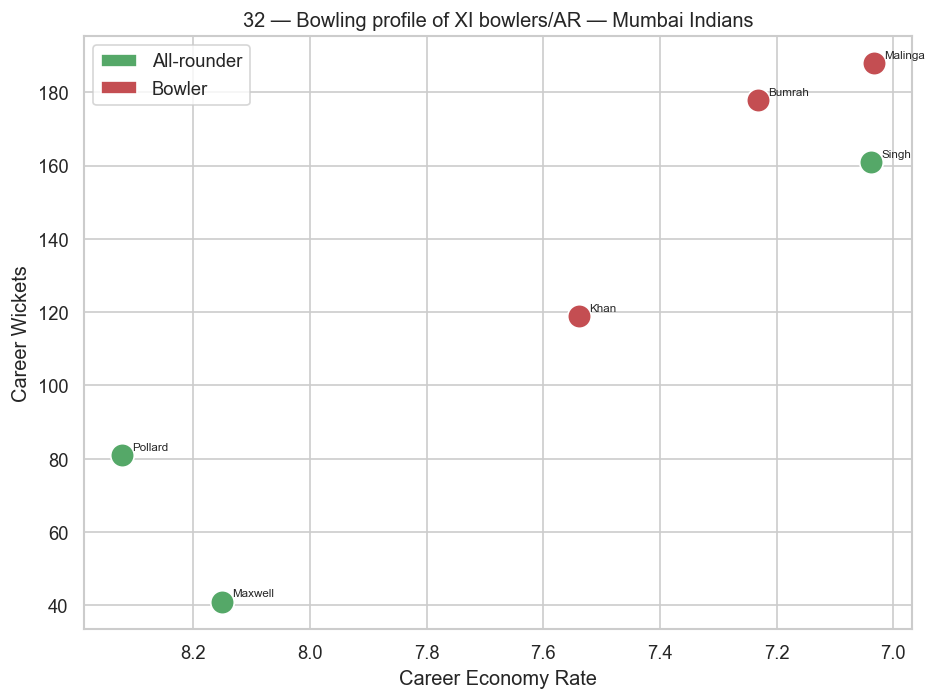

In [43]:
bowl_roles = ['Bowler', 'All-rounder']
sub_bowl   = xi[xi['role'].isin(bowl_roles)].copy()

# Visualisation
if not sub_bowl.empty and 'economy' in sub_bowl.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in sub_bowl.iterrows():
        econ = row.get('economy', 0)
        wkts = row.get('wickets', 0)
        if econ > 50:
            continue
        ax.scatter(econ, wkts, s=200,
                   color=cfg.ROLE_PALETTE.get(row['role'], '#999'),
                   zorder=3, edgecolors='white')
        ax.annotate(row['player'].split()[-1], (econ, wkts),
                    textcoords='offset points', xytext=(6, 3), fontsize=7)
    ax.set_xlabel('Career Economy Rate')
    ax.set_ylabel('Career Wickets')
    ax.set_title(f'32 — Bowling profile of XI bowlers/AR — {franchise}')
    ax.invert_xaxis()  # lower economy = better, so left side is preferred
    leg = [Patch(facecolor=cfg.ROLE_PALETTE.get(r, '#999'), label=r)
           for r in sub_bowl['role'].unique()]
    ax.legend(handles=leg)
    plt.tight_layout()
    plt.show()

### Final Dashboard — Summary Panel

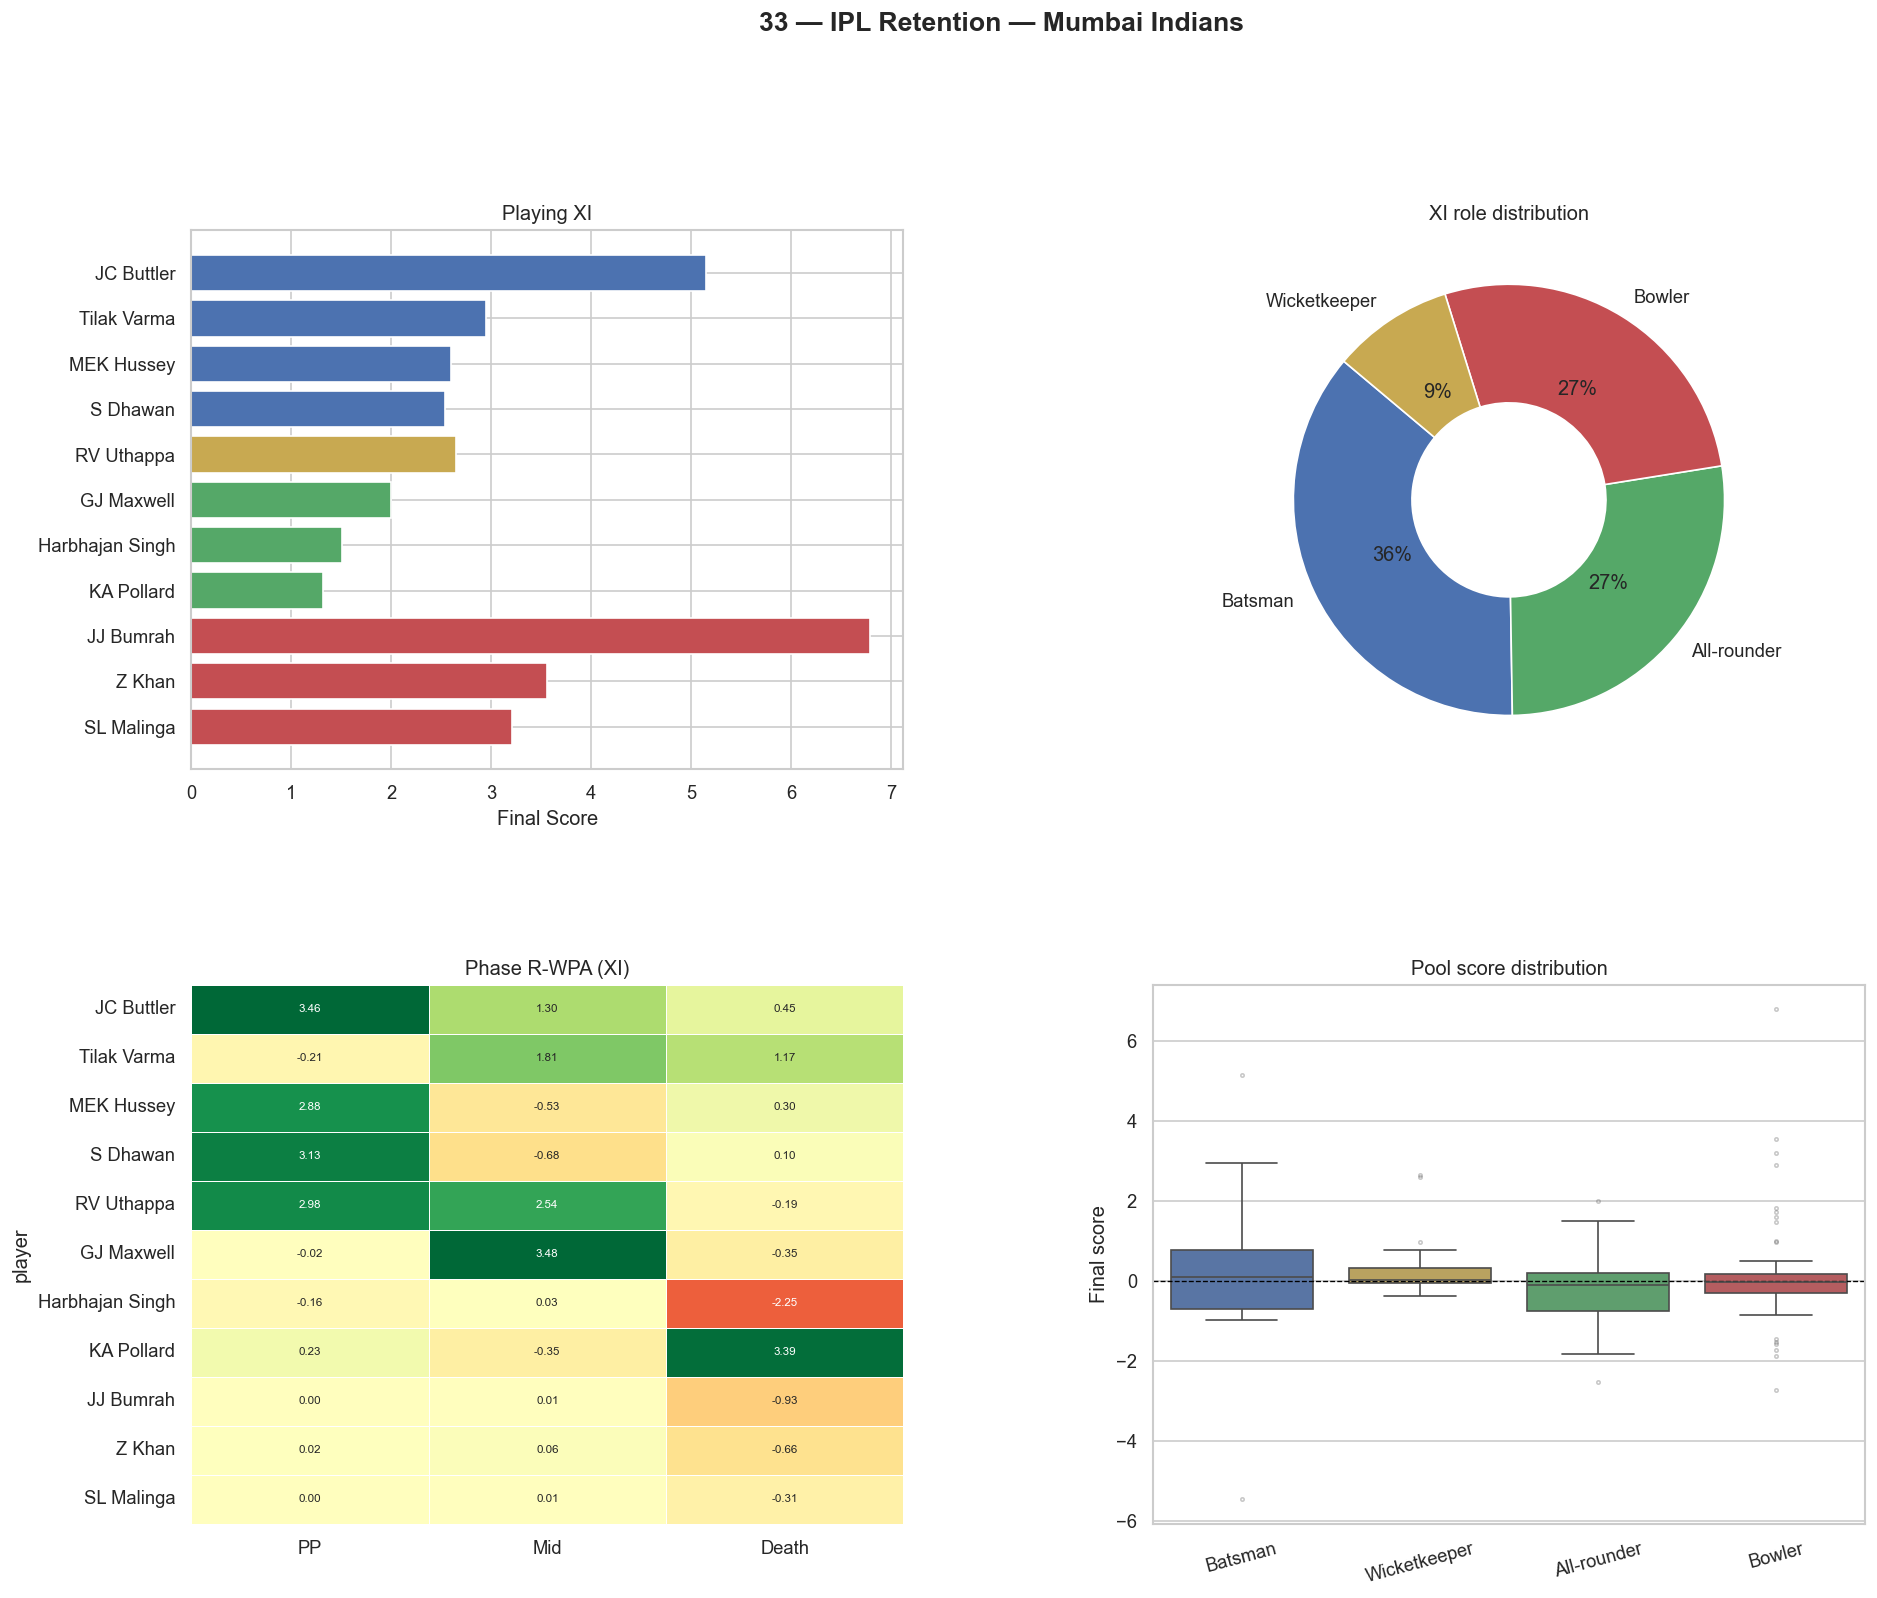

In [44]:
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)
# Visualisation
# Top-left: XI score bar
ax1 = fig.add_subplot(gs[0, 0])
xi_c = xi['role'].map(lambda r: cfg.ROLE_PALETTE.get(r, '#999'))
ax1.barh(xi['player'], xi['final_score'], color=xi_c, edgecolor='white')
ax1.set_xlabel('Final Score')
ax1.invert_yaxis()
ax1.set_title('Playing XI')

# Top-right: role donut
ax2 = fig.add_subplot(gs[0, 1])
xi_counts = xi['role'].value_counts()
xi_clrs   = [cfg.ROLE_PALETTE.get(r, '#999') for r in xi_counts.index]
ax2.pie(xi_counts, labels=xi_counts.index, colors=xi_clrs,
        autopct='%1.0f%%', startangle=140,
        wedgeprops=dict(width=0.55, edgecolor='white'))
ax2.set_title('XI role distribution')

# Bottom-left: phase heatmap
ax3 = fig.add_subplot(gs[1, 0])
if phase_cols:
    heat2 = xi.set_index('player')[phase_cols].fillna(0)
    heat2.columns = ['PP', 'Mid', 'Death'][:len(phase_cols)]
    sns.heatmap(heat2, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, linewidths=0.4, ax=ax3,
                cbar=False, annot_kws={'size': 7})
    ax3.set_title('Phase R-WPA (XI)')

# Bottom-right: pool score boxplot
ax4 = fig.add_subplot(gs[1, 1])
bp_order = [r for r in ['Batsman', 'Wicketkeeper', 'All-rounder', 'Bowler']
            if r in pool['role'].unique()]
sns.boxplot(data=pool, x='role', y='final_score',
            order=bp_order,
            palette={r: cfg.ROLE_PALETTE.get(r, '#999') for r in bp_order},
            ax=ax4, flierprops=dict(marker='o', ms=2, alpha=0.3))
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.set_title('Pool score distribution')
ax4.set_xlabel('')
ax4.set_ylabel('Final score')
plt.xticks(rotation=15)

fig.suptitle(f'33 — IPL Retention — {franchise}',
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

## Export Results

In [45]:
slug      = franchise.replace(' ', '_')
xi_path   = os.path.join(cfg.OUTPUT_DIR, f'playing_xi_{slug}.csv')
pool_path = os.path.join(cfg.OUTPUT_DIR, f'player_pool_{slug}.csv')

xi.to_csv(xi_path, index=True)
pool.sort_values('final_score', ascending=False).to_csv(pool_path, index=False)

print(f' Playing XI saved  = {xi_path}')
print(f' Full pool saved   = {pool_path}')

# Display the final XI as a clean table
display_cols = ['player', 'role', 'combined_ewr_wpa', 'final_score']
display_cols = [c for c in display_cols if c in xi.columns]
xi[display_cols].style.format({
    'combined_ewr_wpa': '{:.3f}',
    'final_score'     : '{:.3f}',
}).background_gradient(subset=['final_score'], cmap='Greens')

 Playing XI saved  = outputs/playing_xi_Mumbai_Indians.csv
 Full pool saved   = outputs/player_pool_Mumbai_Indians.csv


,player,role,combined_ewr_wpa,final_score
1,JC Buttler,Batsman,5.151,5.151
2,Tilak Varma,Batsman,2.678,2.946
3,MEK Hussey,Batsman,2.603,2.603
4,S Dhawan,Batsman,2.534,2.534
5,RV Uthappa,Wicketkeeper,2.649,2.649
6,GJ Maxwell,All-rounder,2.000,2.000
7,Harbhajan Singh,All-rounder,1.506,1.506
8,KA Pollard,All-rounder,1.197,1.317
9,JJ Bumrah,Bowler,6.168,6.785
10,Z Khan,Bowler,3.555,3.555
